# mlr_investigation_friant.ipynb

In [14]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib

In [15]:
sys.path.insert(1, '/home/rossamower/bin/scripts/')

In [16]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing

In [17]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)

<module 'postprocessing' from '/home/rossamower/bin/scripts/postprocessing.py'>

# Inputs

In [18]:
aso_site_name = 'FRIANT'
user_qa_level = 1 #[0 - most conservative; 1 mid; 2 most liberal]
isSplit = False
isAccum = False
aso_stack_type = 'v1'
elev_band = -1
water_year = 1997

## Metadata

In [19]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [20]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

## Misc

In [21]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [22]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [23]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

# Load Input Data

In [24]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

# obs data.
obs_data = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
# obs test.
obs_data_test_ds = obs_data.where(obs_data.time>=np.datetime64(f'{water_year-1}-10-01'), drop = True) \
                       .where(obs_data.time<np.datetime64(f'{water_year}-10-01'), drop = True)    
# obs train.
obs_data_train_ds = obs_data.where(~obs_data.time.isin(obs_data_test_ds.time.values), drop = True)

obs_data_train_lst = dataset_to_list(obs_data_train_ds)
obs_data_test_lst = dataset_to_list(obs_data_test_ds)


# # obs training.
# obs_data_train_ds = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
# obs_data_train_lst = dataset_to_list(obs_data_train_ds)
# # snowmodel 
# sm_train_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_train_2017_2025_dowy.zarr', consolidated=False)
# sm_test_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_test_2026.zarr', consolidated=False)

# # testing raw.
# obs_data_test_ds_raw = xr.load_dataset(f'{insitu_dir}raw/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# # match times.
# obs_data_test_ds_raw = obs_data_test_ds_raw.sel(time = sm_test_ds.time)
# obs_data_test_lst_raw = dataset_to_list(obs_data_test_ds_raw)
# # testing qa.
# obs_data_test_ds = xr.load_dataset(f'{insitu_dir}processed/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# # match times.
# # obs_data_test_ds = obs_data_test_ds.sel(time = sm_test_ds.time)
# obs_data_test_ds = obs_data_test_ds.where(obs_data_test_ds.time.isin(sm_test_ds.time.values),drop = True)
# obs_data_test_lst = dataset_to_list(obs_data_test_ds)
# initial pillow list.
pillows = list(obs_data_test_ds.data_vars)
pillows = [i for i in pillows if i not in exclude_pillows]
# get timing variables.
year_str, month_str, day_str, wy_str = timing_vars(obs_data_test_ds)
# load UASWE data.
# uaswe_acreFt_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_wy{water_year}.csv')
# uaswe_m_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_wy{water_year}.csv')
# # load SNODAS data.
# snodas_acreFt_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_acreFt_wy{water_year}.csv')
# snodas_m_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_m_wy{water_year}.csv')
# # load SnowModel data.
# sm_acreFt_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_acreFt_wy{water_year}.csv')
# sm_m_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_m_wy{water_year}.csv')
# # convert date columns to datetime.
# snodas_acreFt_df['Date'] = pd.to_datetime(snodas_acreFt_df['Date'])
# snodas_m_df['Date'] = pd.to_datetime(snodas_m_df['Date'])
# uaswe_acreFt_df['Date'] = pd.to_datetime(uaswe_acreFt_df['Date'])
# uaswe_m_df['Date'] = pd.to_datetime(uaswe_m_df['Date'])
# sm_acreFt_df['Date'] = pd.to_datetime(sm_acreFt_df['Date'])
# sm_m_df['Date'] = pd.to_datetime(sm_m_df['Date'])

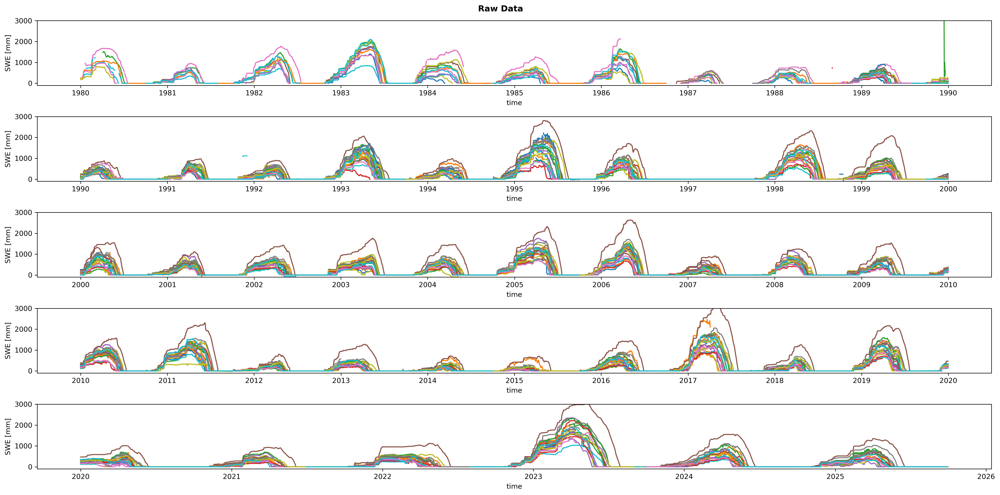

In [25]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(5,1,dpi = 300,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    ds_slice = obs_data_train_ds.where(obs_data_train_ds.time.dt.year >=yr,drop = True) \
                     .where(obs_data_train_ds.time.dt.year <= yr+9,drop = True)
    for pil in ds_slice.data_vars:
        ds_slice[pil].plot(ax=ax[count])
    ax[count].set_ylim(-100,3000)
    ax[count].set_ylabel('SWE [mm]')
    count += 1
    
plt.suptitle('Raw Data',fontweight = 'bold')
plt.tight_layout()

# Load Model Output

In [26]:
def load_model_output(seasonal_dir: str,
                      aso_stack_type: str,
                      mlrPred_dir: str,
                      var: str = 'mm'):
    if var not in ['mm','acreFt','pillows']:
        sys.exit('Incorrect variable passed!')

    output_path = f'{mlrPred_dir}{aso_stack_type}/{seasonal_dir}/{var}/'
    # print(output_path)

    csv_lst = [output_path + i for i in os.listdir(output_path) if '.csv' in i]
    # print(csv_lst)
    count = 0
    for i in sorted(csv_lst):
        if count == 0:
            df_all = pd.read_csv(i)
        else:
            df_all = pd.concat([df_all,pd.read_csv(i)])
        count+=1
    df_all = df_all.reset_index().drop(columns = 'index')
    df_all['Date'] = pd.to_datetime(df_all['Date'])
    df_all["Wateryear"] = np.where((df_all['Date'].dt.month >= 10), df_all['Date'].dt.year+1, df_all['Date'].dt.year)
    
    return df_all


In [27]:
season = 'season'
# v0 --------------------------------------------------
aso_stack_type = 'v0'
var = 'mm' # mm, acreFt, pillows
pred_df_v0_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v0_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v0_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
# v1 --------------------------------------------------
aso_stack_type = 'v1'
var = 'mm' # mm, acreFt, pillows
pred_df_v1_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v1_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v1_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
# v5 --------------------------------------------------
aso_stack_type = 'v5'
var = 'mm' # mm, acreFt, pillows
pred_df_v5_mm = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'acreFt' # mm, acreFt, pillows
pred_df_v5_acreFt = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)
var = 'pillows' # mm, acreFt, pillows
pred_df_v5_pillows = load_model_output(season,
                                  aso_stack_type,
                                  mlrPred_dir,
                                  var)


## v0

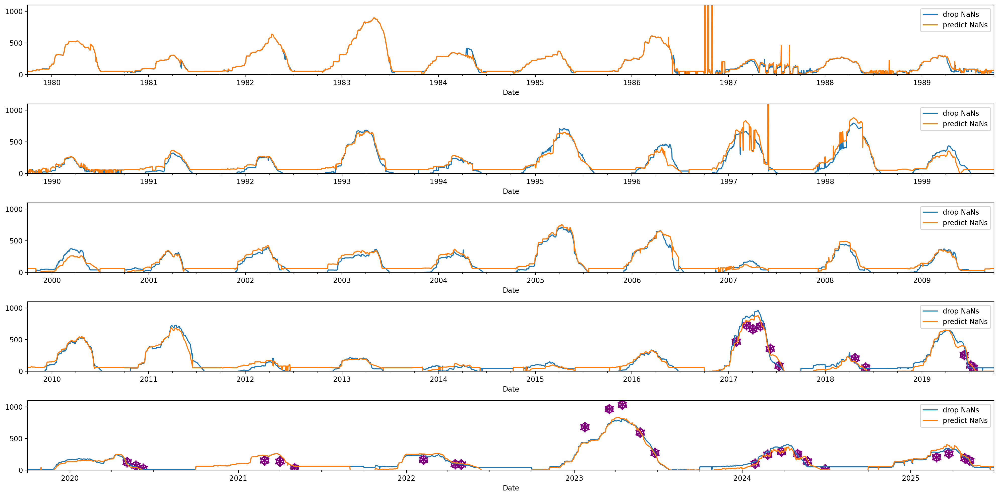

In [28]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v0_mm[(pred_df_v0_mm['Wateryear'] >= yr) & (pred_df_v0_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v1

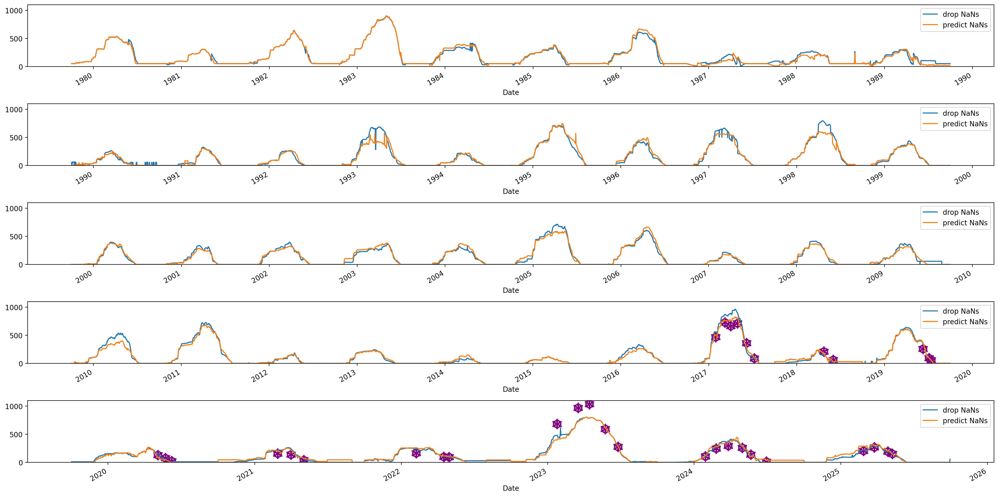

In [29]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice = pred_df_v1_mm[(pred_df_v1_mm['Wateryear'] >= yr) & (pred_df_v1_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice[df_slice['Training Infer NaNs'] == 'drop NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'drop NaNs')
    df_slice[df_slice['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'predict NaNs')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## v0/v1 predicted

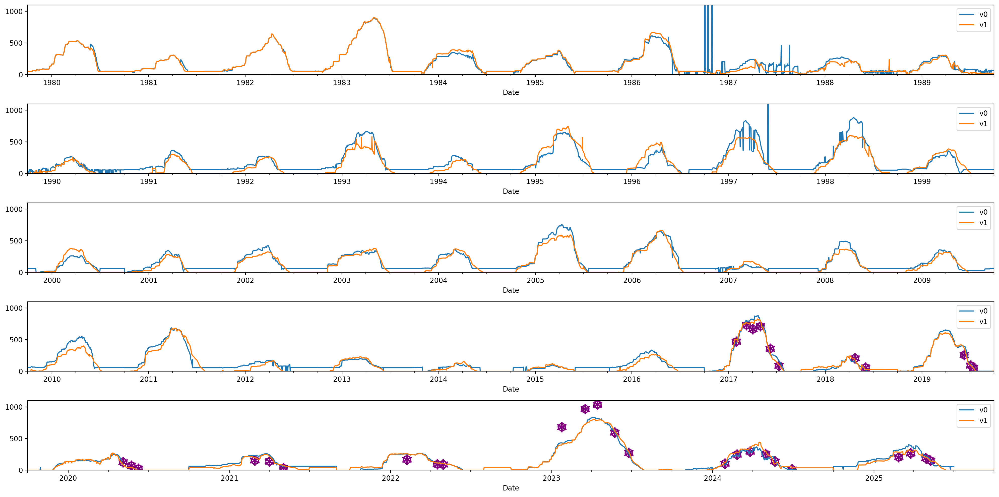

In [30]:
fig,ax = plt.subplots(5,1,dpi = 200,figsize = (20,10))
count = 0
for yr in [1980,1990,2000,2010,2020]:
    df_slice_v1 = pred_df_v1_mm[(pred_df_v1_mm['Wateryear'] >= yr) & (pred_df_v1_mm['Wateryear'] <= yr+9)]
    df_slice_v0 = pred_df_v0_mm[(pred_df_v0_mm['Wateryear'] >= yr) & (pred_df_v0_mm['Wateryear'] <= yr+9)]
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year >= yr).where(aso_tseries_ds.date.dt.year <= yr+9)
    df_slice_v0[df_slice_v0['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C0',label = 'v0')
    df_slice_v1[df_slice_v1['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[count],x = 'Date',y='Basin',color = 'C1',label = 'v1')
    ax[count].scatter(aso_tseries_slice.date.values,aso_tseries_slice.aso_swe[:,-1].values,marker=u'$\u2744$', s=200,color = 'purple',label = 'ASO')
    ax[count].set_ylim(0,1100)
    count += 1
plt.tight_layout()

## ASO vs Model Predictions (v0/v1)

In [31]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

def prediction_v_aso_scatter(aso_tseries_ds: xr.Dataset,
                             pred_df: pd.DataFrame,
                             model_type: str,
                             version: int = 1,
                             elev_idx: int = -1,
                             ):
    aso_df = aso_tseries_ds.aso_swe[:,elev_idx].to_dataframe().drop(columns = 'elev')
    print(f'ASO LENGTH: {len(aso_df)}')
    pred_v1_df = pred_df[(pred_df['Training Infer NaNs'] == model_type) & (pred_df['Date'].isin(aso_tseries_ds.date.values))][['Date','Basin']].rename(columns = {'Date':'date'}).set_index('date')
    print(f'PREDICTION LENGTH: {len(pred_v1_df)}')
    df_merge = pd.merge(left = aso_df,right = pred_v1_df,left_index = True, right_index = True)
    print(f'MERGE LENGTH: {len(df_merge)}')

    r2 = r2_score(df_merge['aso_swe'].values,df_merge['Basin'].values)
    rmse = root_mean_squared_error(df_merge['aso_swe'].values,df_merge['Basin'].values)

    fig,ax = plt.subplots(dpi = 100,figsize = (5,5))
    df_merge.plot(ax=ax,kind = 'scatter',x = 'Basin',y = 'aso_swe',label = f'r2={r2:.2f}\nrmse={rmse:.2f}')
    ax.plot([0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50],[0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50],linestyle = '--',color = 'gray')
    ax.legend()
    plt.xlim(0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50)
    plt.ylim(0,max(df_merge['Basin'].max(),df_merge['aso_swe'].max())+50)
    plt.ylabel('ASO Mean SWE [mm]',fontweight = 'bold')
    plt.xlabel('Predicted Mean SWE [mm]',fontweight = 'bold')
    plt.title(f'v{version} ASO vs Predicted\n{model_type}; {str(aso_tseries_ds.elev[elev_idx].values)}',fontweight = 'bold')
    plt.show()
    return



ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


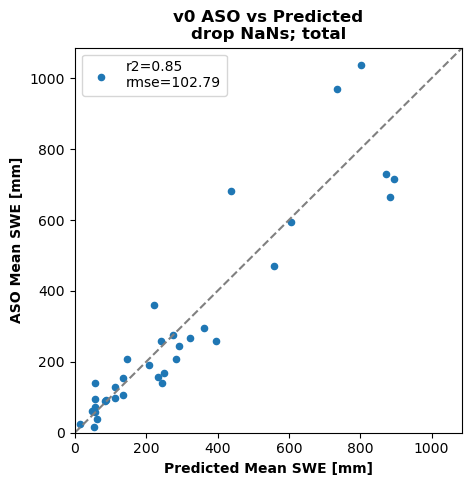

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


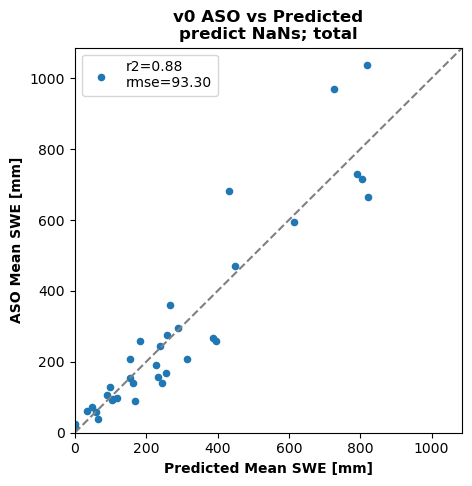

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


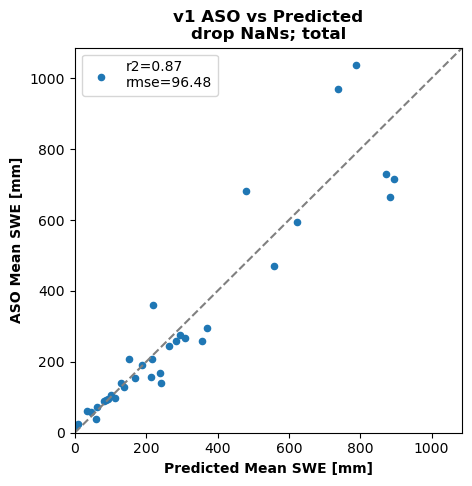

ASO LENGTH: 35
PREDICTION LENGTH: 35
MERGE LENGTH: 35


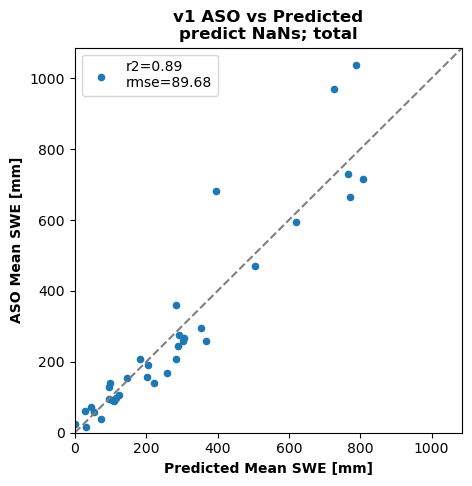

In [32]:
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v0_mm,
                             'drop NaNs',
                             0,
                             elev_idx = -1,
                             )
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v0_mm,
                             'predict NaNs',
                             0,
                             elev_idx = -1,
                             )

prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v1_mm,
                             'drop NaNs',
                             1,
                             elev_idx = -1,
                             )
prediction_v_aso_scatter(aso_tseries_ds,
                             pred_df_v1_mm,
                             'predict NaNs',
                             1,
                             elev_idx = -1,
                             )

In [33]:
aso_df = aso_tseries_ds.aso_swe[:,-1].to_dataframe().drop(columns = 'elev')

## Pillow selection by year

In [34]:
def highlight_dates(ax, dates, *, span_kw=None, line_kw=None):
    """
    On the given Axes:
      - fill (axvspan) continuous runs of consecutive dates (>=2 days),
      - draw axvline for single, isolated dates.
    """
    span_kw = {"color": "C0", "alpha": 0.2} | (span_kw or {})
    line_kw = {"color": "C0", "alpha": 0.8, "lw": 1.5} | (line_kw or {})

    idx = pd.to_datetime(pd.Index(dates)).tz_localize(None).sort_values().unique()
    if len(idx) == 0:
        return

    s = pd.Series(idx)
    grp = (s.diff().ne(pd.Timedelta(days=1))).cumsum()
    for _, run in s.groupby(grp):
        if len(run) == 1:
            ax.axvline(run.iloc[0], **line_kw)
        else:
            start = run.iloc[0]
            end = run.iloc[-1] + pd.Timedelta(days=1)
            ax.axvspan(start, end, **span_kw)


# Mapping between pred_df/pils_df elevation column names (left) and the
# aso_tseries_ds 'elev' coordinate labels (right). Same boundaries, two
# different naming conventions across the codebase.
ELEV_BIN_MAP = {
    '<7k':     '<7000',
    '7k-8k':   '7000-8000',
    '8k-9k':   '8000-9000',
    '9k-10k':  '9000-10000',
    '10k-11k': '10000-11000',
    '11k-12k': '11000-12000',
    '>12k':    '>12000',
    'Basin':   'total',
}


def prediction_pillows_tseries(pred_df: pd.DataFrame,
                               pils_df: pd.DataFrame,
                               aso_tseries_ds: xr.Dataset,
                               obs_data_hist: xr.Dataset,
                               water_year: int,
                               model_type: str = 'predict NaNs',
                               version: int = 1,
                               suspect_delta_mm: float = 40.0,
                               elev_label: str = 'Basin'):
    """
    Six-panel QA overview for one water year:
      0) drop NaNs vs predict NaNs `elev_label` SWE predictions + ASO scatter
      1) all active pillows in the WY (context)
      2) drop NaNs pillows used (union of any pillow ever selected by drop NaNs)
      3) drop NaNs selection Gantt strip (which pillow was selected each day)
      4) predict NaNs pillows used (union)
      5) predict NaNs selection Gantt strip

    `elev_label` selects which elevation band to visualize. Accepts one of
    the pred_df/pils_df column names: '<7k', '7k-8k', '8k-9k', '9k-10k',
    '10k-11k', '11k-12k', '>12k', or 'Basin' (default = basin mean).

    Vertical red dashed lines highlight dates where either prediction has
    |day-over-day delta| > `suspect_delta_mm` (default 40 mm/day) -- likely
    model-swap or bad-value artifacts. Pillow colors are consistent across
    panels 2-5: same pillow's line in the upper panel matches its row color
    in the Gantt strip below.
    """
    from matplotlib.gridspec import GridSpec

    if elev_label not in ELEV_BIN_MAP:
        raise ValueError(
            f"elev_label={elev_label!r} not recognised. "
            f"Choose one of: {list(ELEV_BIN_MAP)}")
    aso_elev = ELEV_BIN_MAP[elev_label]

    wy_start = np.datetime64(f'{water_year-1}-10-01')
    wy_end   = np.datetime64(f'{water_year}-10-01')

    pred_QA_mm = pred_df[pred_df['Wateryear'] == water_year]
    pillows_QA_mm = pils_df[pils_df['Wateryear'] == water_year]

    # split predictions + pillow-selection rows by training-NaNs mode
    drop_pred    = pred_QA_mm[pred_QA_mm['Training Infer NaNs'] == 'drop NaNs'].copy()
    predict_pred = pred_QA_mm[pred_QA_mm['Training Infer NaNs'] == 'predict NaNs'].copy()
    drop_rows    = pillows_QA_mm[pillows_QA_mm['Training Infer NaNs'] == 'drop NaNs']
    predict_rows = pillows_QA_mm[pillows_QA_mm['Training Infer NaNs'] == 'predict NaNs']

    def _union_pils(rows):
        return sorted(set(
            p.strip()
            for cell_str in rows[elev_label]
            for p in str(cell_str).split(',')
            if p.strip()
        ))
    drop_pils    = _union_pils(drop_rows)
    predict_pils = _union_pils(predict_rows)

    # consistent color map across panels 2-5
    all_used_pils = sorted(set(drop_pils) | set(predict_pils))
    pil_colors = {p: f'C{i % 10}' for i, p in enumerate(all_used_pils)}

    # all active pillows in this WY (context for panel 1; default cycle is fine)
    obs_data_wy = obs_data_hist.where(obs_data_hist.time >= wy_start, drop=True) \
                                .where(obs_data_hist.time <  wy_end,   drop=True)
    active_pils = [p for p in obs_data_wy.data_vars
                   if int(obs_data_wy[p].isnull().sum()) < obs_data_wy[p].shape[0]]

    # suspect dates: |day-over-day delta| > threshold in either prediction
    def _suspect_from(pred_subset):
        if len(pred_subset) == 0:
            return []
        s = pred_subset.sort_values('Date').set_index('Date')[elev_label]
        deltas = s.diff().abs()
        return list(s.index[deltas > suspect_delta_mm])
    suspect_dates = sorted(set(
        pd.Timestamp(d) for d in (_suspect_from(drop_pred) + _suspect_from(predict_pred))
    ))

    # ---- figure ----
    fig = plt.figure(figsize=(13, 13), dpi=150)
    height_ratios = [1.5, 1.5, 1.5, 0.8, 1.5, 0.8]
    gs = GridSpec(6, 1, figure=fig, height_ratios=height_ratios, hspace=0.45)
    ax_pred       = fig.add_subplot(gs[0, 0])
    ax_all        = fig.add_subplot(gs[1, 0])
    ax_drop       = fig.add_subplot(gs[2, 0])
    ax_drop_g     = fig.add_subplot(gs[3, 0])
    ax_pred_pils  = fig.add_subplot(gs[4, 0])
    ax_pred_g     = fig.add_subplot(gs[5, 0])
    axes = [ax_pred, ax_all, ax_drop, ax_drop_g, ax_pred_pils, ax_pred_g]
    for a in axes[1:]:
        a.sharex(ax_pred)

    # ---- panel 0: predictions ----
    aso_tseries_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year == water_year)
    aso_elev_vals = aso_tseries_slice.aso_swe.sel(elev=aso_elev).values
    if len(drop_pred):
        drop_pred.plot(ax=ax_pred, x='Date', y=elev_label, color='C0', label='drop NaNs')
    if len(predict_pred):
        predict_pred.plot(ax=ax_pred, x='Date', y=elev_label, color='C1', label='predict NaNs')
    ax_pred.scatter(aso_tseries_slice.date.values,
                    aso_elev_vals,
                    marker=u'$❄$', s=200, color='purple', label='ASO')
    title = f'v{version} {elev_label} SWE Predictions: {water_year}'
    if suspect_dates:
        title += f'   ({len(suspect_dates)} suspect day(s) flagged in red)'
    ax_pred.set_title(title, fontweight='bold')
    ax_pred.set_ylabel(f'{elev_label} Mean SWE [mm]')
    ax_pred.legend(loc='upper right', fontsize=8)

    # ---- panel 1: all active pillows ----
    for pil in active_pils:
        obs_data_wy[pil].plot(ax=ax_all, label=pil, linewidth=0.8)
    ax_all.set_title(f'All Active Pillows: WY {water_year}', fontweight='bold')
    ax_all.set_ylabel('SWE [mm]')
    ax_all.legend(loc='upper right', ncols=4, fontsize=6)

    def _plot_pils(ax, pils, label):
        """Time series of selected pillows for this model type."""
        for pil in pils:
            if pil in obs_data_wy.data_vars:
                obs_data_wy[pil].plot(ax=ax, label=pil, linewidth=1.2,
                                      color=pil_colors.get(pil))
        ax.set_ylabel('SWE [mm]')
        ax.legend(loc='upper right', ncols=4, fontsize=7)
        ax.set_title(
            f'{label} Pillows Used ({len(pils)}): {", ".join(pils) if pils else "(none)"}',
            fontweight='bold')

    def _plot_gantt(ax, pils, rows, label):
        """Per-pillow per-day selection strip. Each pillow gets its own row."""
        if not pils or len(rows) == 0:
            ax.text(0.5, 0.5, f'(no {label} selections this year)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='#888')
            ax.set_xticks([]); ax.set_yticks([])
            return
        idx = pd.date_range(pd.Timestamp(wy_start),
                            pd.Timestamp(wy_end) - pd.Timedelta(days=1),
                            freq='D')
        pil_to_set = {p: set() for p in pils}
        for _, r in rows.iterrows():
            d = pd.Timestamp(r['Date']).normalize()
            for p in str(r[elev_label]).split(','):
                p = p.strip()
                if p in pil_to_set:
                    pil_to_set[p].add(d)
        n = len(pils)
        band_h = 1.0 / n
        for i, pil in enumerate(pils):
            sel = pd.Series([d in pil_to_set[pil] for d in idx], index=idx).astype(int)
            ax.fill_between(sel.index,
                            i * band_h, (i + 0.85) * band_h,
                            where=sel.astype(bool).values,
                            color=pil_colors.get(pil, 'gray'),
                            alpha=0.75, step='post')
        ax.set_yticks([(i + 0.425) * band_h for i in range(n)])
        ax.set_yticklabels(pils, fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(f'{label} Selection Gantt', fontweight='bold', fontsize=10)
        ax.grid(False)

    # ---- panels 2 & 3: drop NaNs pillows + Gantt ----
    _plot_pils(ax_drop, drop_pils, 'drop NaNs')
    _plot_gantt(ax_drop_g, drop_pils, drop_rows, 'drop NaNs')

    # ---- panels 4 & 5: predict NaNs pillows + Gantt ----
    _plot_pils(ax_pred_pils, predict_pils, 'predict NaNs')
    _plot_gantt(ax_pred_g, predict_pils, predict_rows, 'predict NaNs')

    # ---- suspect-date vertical lines across every panel ----
    for d in suspect_dates:
        for a in axes:
            a.axvline(d, color='red', linestyle='--', linewidth=0.8,
                      alpha=0.7, zorder=10)

    plt.tight_layout()
    plt.show()

    if suspect_dates:
        print(f'  suspect dates (|Δ| > {suspect_delta_mm:.0f} mm/day): '
              + ', '.join(d.strftime('%Y-%m-%d') for d in suspect_dates))
    return


def pillows_tseries(           
        obs_data_hist: xr.Dataset,
        water_year: int
        ):
    
    fig,ax = plt.subplots(figsize = (9,5))
    for pil in obs_data_hist.data_vars:
        pil_da = obs_data_hist.where(obs_data_hist.time >= np.datetime64(f'{water_year-1}-10-01'),drop = True) \
                     .where(obs_data_hist.time < np.datetime64(f'{water_year}-10-01'),drop = True)[pil]
        if int(pil_da.isnull().sum()) == pil_da.shape[0]:
            pass 
        else:
            pil_da.plot(ax=ax,label = pil)
    plt.legend(ncols = 3,fontsize = 6)
    plt.show()
    wy_input = bool(int(input('All pillows look good? [Yes = 1; No = 0]')))
    if wy_input:
        pass
    else:
        for pil in obs_data_hist.data_vars:
            fig,ax = plt.subplots(figsize = (9,5))
            obs_data_hist.where(obs_data_hist.time >= np.datetime64(f'{water_year-1}-10-01'),drop = True) \
                     .where(obs_data_hist.time < np.datetime64(f'{water_year}-10-01'),drop = True)[pil].plot(ax=ax,label = pil)
            plt.legend()
            plt.show()
    return pil_da

In [35]:
import matplotlib.dates as mdates

def _add_date_grid(ax, locator=None):
    """Add vertical date gridlines to an axes."""
    ax.xaxis.set_major_locator(locator or mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, axis='x', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.tick_params(axis='x', labelrotation=30, labelsize=7)


def manual_pillow_qa(obs_data_ds,
                     pred_df,
                     pils_df,
                     aso_tseries_ds,
                     water_years,
                     model_type='predict NaNs',
                     version=1,
                     resume=True,
                     qa_nc_path=None,
                     qa_log_path=None,
                     reviewed_path=None,
                     elev_label='Basin',
                     obs_data_overlay=None,
                     mark_reviewed=True,
                     logMode=True):
    """
    Interactive year-by-year manual QA for pillow SWE data.

    Resumable: state is persisted after every confirmed removal, after every
    year completes, on KeyboardInterrupt, and in a finally block.
    Set `resume=False` to start completely fresh (ignores any saved state).

    Default artifacts under {insitu_dir}processed/ (override via kwargs):
      - pillow_wy_1980_2025_qa2.nc       : the masked dataset
      - manual_qa_log.csv                : one row per (pil, range) removed
      - manual_qa_reviewed_years.csv     : years marked done (skipped on resume)

    Parameters added for v6 / multi-elevation review
    -------------------------------------------------
    elev_label : str
        Elevation band the prediction-context panel focuses on (passed to
        prediction_pillows_tseries). Default 'Basin' preserves v2 behavior.
    obs_data_overlay : list of (xr.Dataset, label, color) or None
        Additional datasets to overlay as dashed lines on each individual
        pillow plot, e.g. [(obs_data_v1, 'v1', 'C7')]. Default None.
    mark_reviewed : bool
        Whether to add the WY to reviewed_years on completion. Default True.
        Set False when an outer orchestrator (e.g. manual_pillow_qa_v6)
        manages reviewed-year tracking itself.
    logMode : bool
        When True (default), state is persisted to disk after each removal
        and on year completion (original behavior). When False, the function
        runs in DRY-RUN mode: plots and prompts still happen and in-memory
        modifications are made (and returned), but no .nc / .csv files are
        written. Useful for previewing the QA flow without side effects.
    """
    import copy, os

    # default paths
    base = f'{insitu_dir}processed/'
    if qa_nc_path is None:
        qa_nc_path = f'{base}pillow_wy_1980_2025_qa2.nc'
    if qa_log_path is None:
        qa_log_path = f'{base}manual_qa_log.csv'
    if reviewed_path is None:
        reviewed_path = f'{base}manual_qa_reviewed_years.csv'

    # --- initialize / resume state ---
    if resume and os.path.exists(qa_nc_path):
        print(f'Resuming from {qa_nc_path}')
        obs_data_qa = xr.load_dataset(qa_nc_path)
    else:
        print('Starting fresh (deep copy of input dataset).')
        obs_data_qa = copy.deepcopy(obs_data_ds)

    if resume and os.path.exists(qa_log_path):
        qa_log = pd.read_csv(qa_log_path).to_dict('records')
        print(f'Loaded {len(qa_log)} prior removal(s) from log.')
    else:
        qa_log = []

    if resume and os.path.exists(reviewed_path):
        reviewed_years = set(int(y) for y in pd.read_csv(reviewed_path)['water_year'].tolist())
        print(f'Already-reviewed years (will skip): {sorted(reviewed_years)}')
    else:
        reviewed_years = set()
        if resume and len(qa_log) > 0:
            inferred = sorted(set(int(r['water_year']) for r in qa_log))
            print(f'No reviewed_years file found, but log contains entries for years {inferred}. '
                  'These years will be RE-REVIEWED. To skip them, manually create '
                  f'{reviewed_path} with one "water_year" column listing the years.')

    if not logMode:
        print('*** DRY-RUN MODE (logMode=False): plots/prompts run, '
              'but NO .nc/.csv writes will occur. ***')

    def _persist():
        """Save current state to disk. No-op when logMode=False."""
        if not logMode:
            return
        obs_data_qa.to_netcdf(qa_nc_path)
        pd.DataFrame(qa_log).to_csv(qa_log_path, index=False)
        pd.DataFrame({'water_year': sorted(reviewed_years)}).to_csv(reviewed_path, index=False)

    try:
        for wy in water_years:
            if wy in reviewed_years:
                print(f'  WY {wy}: already reviewed -- skipping. '
                      f'(Remove {wy} from {reviewed_path} or pass resume=False to redo.)')
                continue

            wy_start = np.datetime64(f'{wy-1}-10-01')
            wy_end   = np.datetime64(f'{wy}-10-01')

            ds_slice = obs_data_qa.where(obs_data_qa.time >= wy_start, drop=True) \
                                  .where(obs_data_qa.time < wy_end,   drop=True)

            active_pils = [p for p in ds_slice.data_vars
                           if int(ds_slice[p].isnull().sum()) < ds_slice[p].shape[0]]
            if not active_pils:
                if mark_reviewed:
                    reviewed_years.add(wy)
                _persist()
                print(f'  WY {wy}: no active pillows; auto-marked reviewed.' if mark_reviewed
                      else f'  WY {wy}: no active pillows.')
                continue

            print(f"\n{'='*50}  WY {wy}  ({elev_label})  {'='*50}")

            # Overview: model prediction + all pillows + used pillows
            prediction_pillows_tseries(pred_df, pils_df, aso_tseries_ds, obs_data_qa,
                                       wy, model_type=model_type, version=version,
                                       elev_label=elev_label)

            # Individual pillow plots with monthly gridlines
            n = len(active_pils)
            fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), dpi=150, sharex=True)
            if n == 1:
                axes = [axes]
            for i, (ax, pil) in enumerate(zip(axes, active_pils)):
                ds_slice[pil].plot(ax=ax, color='C0',
                                   label=f'v{version}' if obs_data_overlay else None)
                if obs_data_overlay:
                    for overlay_ds, overlay_label, overlay_color in obs_data_overlay:
                        if pil in overlay_ds.data_vars:
                            ov_slice = overlay_ds[pil].where(
                                overlay_ds.time >= wy_start, drop=True).where(
                                overlay_ds.time < wy_end, drop=True)
                            if int(ov_slice.notnull().sum()) > 0:
                                ov_slice.plot(ax=ax, color=overlay_color,
                                              linestyle='--', linewidth=0.8, alpha=0.6,
                                              label=overlay_label)
                    if i == 0:
                        ax.legend(loc='upper right', fontsize=6)
                ax.set_title(pil, fontsize=8)
                ax.set_ylabel('SWE [mm]')
                _add_date_grid(ax)
            plt.suptitle(f'WY {wy} -- individual pillows', fontweight='bold')
            plt.tight_layout()
            plt.show()

            wy_ok = bool(int(input(f'WY {wy}: All pillows look good?  [Yes=1 / No=0]: ')))
            if wy_ok:
                if mark_reviewed:
                    reviewed_years.add(wy)
                _persist()
                print(f'  WY {wy}: marked clean, state saved.' if mark_reviewed
                      else f'  WY {wy}: clean for this pass, state saved.')
                continue

            # Flagging loop -- repeat until user types 'done'
            while True:
                print(f"  Active pillows: {active_pils}")
                pil_name = input("  Pillow to flag (or 'done' to move to next year): ").strip()
                if pil_name.lower() == 'done':
                    break
                if pil_name not in obs_data_qa.data_vars:
                    print(f"  '{pil_name}' not recognised. Available: {list(obs_data_qa.data_vars)}")
                    continue

                # Optional zoom-in before entering NaN dates
                do_zoom = bool(int(input("    Zoom in to inspect? [Yes=1 / No=0]: ")))
                if do_zoom:
                    z_start = input("      Zoom from (YYYY-MM-DD): ").strip()
                    z_end   = input("      Zoom to   (YYYY-MM-DD): ").strip()
                    try:
                        zt0 = np.datetime64(z_start)
                        zt1 = np.datetime64(z_end)
                    except (ValueError, TypeError) as e:
                        print(f"      Date parse error: {e}, skipping zoom.")
                    else:
                        fig, ax = plt.subplots(figsize=(9, 2.5), dpi=150)
                        obs_data_qa[pil_name].where(obs_data_qa.time >= zt0, drop=True) \
                                             .where(obs_data_qa.time <= zt1, drop=True) \
                                             .plot(ax=ax, color='C0')
                        _add_date_grid(ax, mdates.AutoDateLocator())
                        ax.set_title(f'{pil_name}  zoom: {z_start} to {z_end}', fontweight='bold')
                        plt.tight_layout()
                        plt.show()

                start_str = input("    Remove from (YYYY-MM-DD): ").strip()
                end_str   = input("    Remove to   (YYYY-MM-DD): ").strip()
                try:
                    t0 = np.datetime64(start_str)
                    t1 = np.datetime64(end_str)
                except (ValueError, TypeError) as e:
                    print(f"    Date parse error: {e}")
                    continue

                # Preview: plot flagged range before committing
                fig, ax = plt.subplots(figsize=(9, 2.5), dpi=150)
                obs_data_qa[pil_name].where(obs_data_qa.time >= wy_start, drop=True) \
                                      .where(obs_data_qa.time < wy_end,   drop=True) \
                                      .plot(ax=ax, color='C0')
                ax.axvline(pd.Timestamp(start_str), color='C3', linewidth=1.5,
                           linestyle='--', label=f'start: {start_str}')
                ax.axvline(pd.Timestamp(end_str),   color='C3', linewidth=1.5,
                           linestyle='--', label=f'end:   {end_str}')
                ax.axvspan(pd.Timestamp(start_str), pd.Timestamp(end_str),
                           color='C3', alpha=0.2, label='flagged range')
                _add_date_grid(ax)
                ax.legend(fontsize=7)
                ax.set_title(f'{pil_name}  WY {wy}  -- flagged range preview', fontweight='bold')
                plt.tight_layout()
                plt.show()

                confirm = bool(int(input(f"    Confirm removal {start_str} to {end_str}? [Yes=1 / No=0]: ")))
                if not confirm:
                    print("    Skipped -- re-enter dates or type 'done' to move on.")
                    continue

                mask = (obs_data_qa.time >= t0) & (obs_data_qa.time <= t1)
                obs_data_qa[pil_name] = obs_data_qa[pil_name].where(~mask)
                n_nulled = int(mask.sum())
                qa_log.append(dict(water_year=wy, pillow=pil_name,
                                   start=start_str, end=end_str,
                                   n_values_removed=n_nulled))
                # Persist after each removal so a kernel crash mid-year is safe.
                _persist()
                print(f"    Nulled {n_nulled} values for {pil_name} ({start_str} to {end_str}); saved.")

                # Post-QA confirmation plot
                fig, ax = plt.subplots(figsize=(9, 2.5), dpi=150)
                obs_data_qa[pil_name].where(obs_data_qa.time >= wy_start, drop=True) \
                                      .where(obs_data_qa.time < wy_end,   drop=True) \
                                      .plot(ax=ax, color='C0')
                _add_date_grid(ax)
                ax.set_title(f'{pil_name}  WY {wy}  (after QA)', fontweight='bold')
                plt.tight_layout()
                plt.show()

            # done with flagging for this year
            if mark_reviewed:
                reviewed_years.add(wy)
            _persist()
            print(f'  WY {wy}: complete, state saved.' if mark_reviewed
                  else f'  WY {wy}: pass complete, state saved.')

    except KeyboardInterrupt:
        print('\nInterrupted -- saving progress before exit.')
        _persist()
        raise
    finally:
        _persist()

    cols = ['water_year', 'pillow', 'start', 'end', 'n_values_removed']
    qa_log_df = pd.DataFrame(qa_log, columns=cols) if qa_log else pd.DataFrame(columns=cols)
    print("\n-- QA Log --")
    print(qa_log_df.to_string(index=False))
    return obs_data_qa, qa_log_df


In [36]:
def inspect_water_years(obs_data_ds,
                        water_years,
                        pred_df=None,
                        pils_df=None,
                        aso_tseries_ds=None,
                        model_type='predict NaNs',
                        version=None,
                        elev_label='Basin'):
    """
    Read-only inspection of pillow time series by water year.

    No writes, no input prompts, no state changes. Use this to:
      - Decide whether a particular WY needs manual QA before invoking
        manual_pillow_qa()
      - Eyeball model predictions against pillow values for any version
        without risk of mutating qa2.nc or its log

    Parameters
    ----------
    obs_data_ds : xr.Dataset
        The pillow dataset to view (qa1, qa2, qa3, qa5, ...).
    water_years : int or list[int]
        Single WY or list of WYs to inspect.
    pred_df, pils_df, aso_tseries_ds : optional
        If ALL THREE are provided, the per-WY context panel from
        prediction_pillows_tseries() is rendered with predictions + ASO
        scatter for `elev_label`. If any is None, that panel is skipped
        and only the per-pillow plots are shown.
    model_type : str
        'predict NaNs' or 'drop NaNs' -- passed through to the context panel.
    version : int or None
        Display label only (e.g. 1, 3, 5). Defaults to 0 if not provided.
    elev_label : str
        Elevation band label from ELEV_BIN_MAP, default 'Basin'.
    """
    if isinstance(water_years, int):
        water_years = [water_years]

    has_predictions = (pred_df is not None and pils_df is not None
                       and aso_tseries_ds is not None)

    for wy in water_years:
        wy_start = np.datetime64(f'{wy-1}-10-01')
        wy_end   = np.datetime64(f'{wy}-10-01')

        ds_slice = obs_data_ds.where(obs_data_ds.time >= wy_start, drop=True) \
                              .where(obs_data_ds.time <  wy_end,   drop=True)
        active_pils = [p for p in ds_slice.data_vars
                       if int(ds_slice[p].isnull().sum()) < ds_slice[p].shape[0]]

        print(f"\n{'='*50}  WY {wy}  {'='*50}")

        if not active_pils:
            print(f'  WY {wy}: no active pillows -- skipping.')
            continue

        # Context panel (predictions + selected-pillow Gantt) if data provided
        if has_predictions:
            prediction_pillows_tseries(pred_df, pils_df, aso_tseries_ds, obs_data_ds,
                                       wy, model_type=model_type,
                                       version=version if version is not None else 0,
                                       elev_label=elev_label)

        # Per-pillow time series
        n = len(active_pils)
        fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), dpi=150, sharex=True)
        if n == 1:
            axes = [axes]
        for ax, pil in zip(axes, active_pils):
            ds_slice[pil].plot(ax=ax)
            ax.set_title(pil, fontsize=8)
            ax.set_ylabel('SWE [mm]')
            _add_date_grid(ax)
        plt.suptitle(f'WY {wy} -- individual pillows', fontweight='bold')
        plt.tight_layout()
        plt.show()

In [37]:
def inspect_water_years(obs_data_ds,
                        water_years,
                        pred_df=None,
                        pils_df=None,
                        aso_tseries_ds=None,
                        model_type='predict NaNs',
                        version=None,
                        elev_label='Basin'):
    """
    Read-only inspection of pillow time series by water year.

    No writes, no input prompts, no state changes. Use this to:
      - Decide whether a particular WY needs manual QA before invoking
        manual_pillow_qa()
      - Eyeball model predictions against pillow values for any version
        without risk of mutating qa2.nc or its log

    Parameters
    ----------
    obs_data_ds : xr.Dataset
        The pillow dataset to view (qa1, qa2, qa3, qa5, ...).
    water_years : int or list[int]
        Single WY or list of WYs to inspect.
    pred_df, pils_df, aso_tseries_ds : optional
        If ALL THREE are provided, the per-WY context panel from
        prediction_pillows_tseries() is rendered with predictions + ASO
        scatter for `elev_label`. If any is None, that panel is skipped
        and only the per-pillow plots are shown.
    model_type : str
        'predict NaNs' or 'drop NaNs' -- passed through to the context panel.
    version : int or None
        Display label only (e.g. 1, 3, 5). Defaults to 0 if not provided.
    elev_label : str
        Elevation band label from ELEV_BIN_MAP, default 'Basin'.
    """
    if isinstance(water_years, int):
        water_years = [water_years]

    has_predictions = (pred_df is not None and pils_df is not None
                       and aso_tseries_ds is not None)

    for wy in water_years:
        wy_start = np.datetime64(f'{wy-1}-10-01')
        wy_end   = np.datetime64(f'{wy}-10-01')

        ds_slice = obs_data_ds.where(obs_data_ds.time >= wy_start, drop=True) \
                              .where(obs_data_ds.time <  wy_end,   drop=True)
        active_pils = [p for p in ds_slice.data_vars
                       if int(ds_slice[p].isnull().sum()) < ds_slice[p].shape[0]]

        print(f"\n{'='*50}  WY {wy}  {'='*50}")

        if not active_pils:
            print(f'  WY {wy}: no active pillows -- skipping.')
            continue

        # Context panel (predictions + selected-pillow Gantt) if data provided
        if has_predictions:
            prediction_pillows_tseries(pred_df, pils_df, aso_tseries_ds, obs_data_ds,
                                       wy, model_type=model_type,
                                       version=version if version is not None else 0,
                                       elev_label=elev_label)

        # Per-pillow time series
        n = len(active_pils)
        fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), dpi=150, sharex=True)
        if n == 1:
            axes = [axes]
        for ax, pil in zip(axes, active_pils):
            ds_slice[pil].plot(ax=ax)
            ax.set_title(pil, fontsize=8)
            ax.set_ylabel('SWE [mm]')
            _add_date_grid(ax)
        plt.suptitle(f'WY {wy} -- individual pillows', fontweight='bold')
        plt.tight_layout()
        plt.show()

# Manual Pillow QA

## Original v2

In [24]:
start_wy = 1980
end_wy = 2025

In [25]:
# water_years = list(range(start_wy, end_wy + 1))

# obs_data_qa, qa_log_df = manual_pillow_qa(
#     obs_data_train_ds,
#     pred_df_v1_mm,
#     pred_df_v1_pillows,
#     aso_tseries_ds,
#     water_years,
#     model_type='predict NaNs',
#     version=1,
# )

In [ ]:
# Save QA log and QA'd dataset
# qa_log_df.to_csv(f'{insitu_dir}processed/manual_qa_log.csv', index=False)
# obs_data_qa.to_netcdf(f'{insitu_dir}processed/pillow_wy_1980_2025_qa2.nc')
# print(f'Saved QA log ({len(qa_log_df)} removals) and qa2 netcdf.')

## Investigation


==================================================  WY 1997  ==================================================


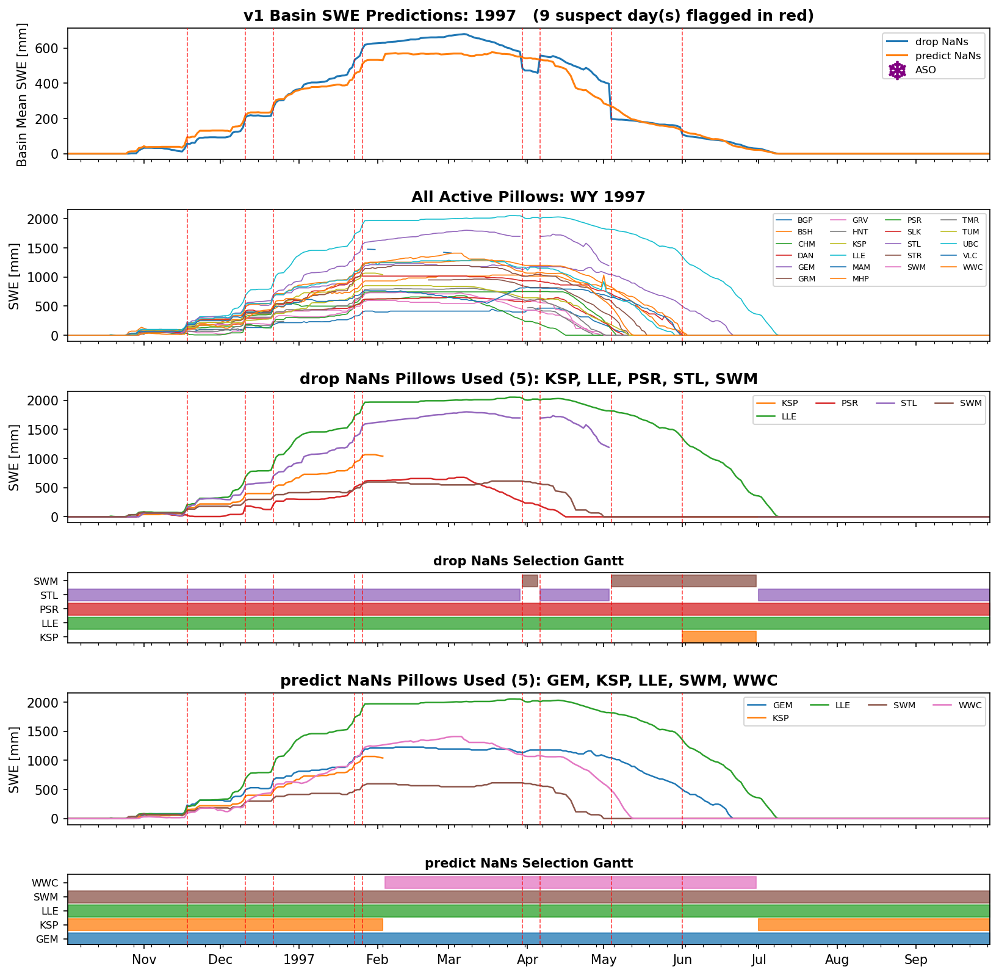

  suspect dates (|Δ| > 40 mm/day): 1996-11-18, 1996-12-11, 1996-12-22, 1997-01-23, 1997-01-26, 1997-03-30, 1997-04-06, 1997-05-04, 1997-06-01


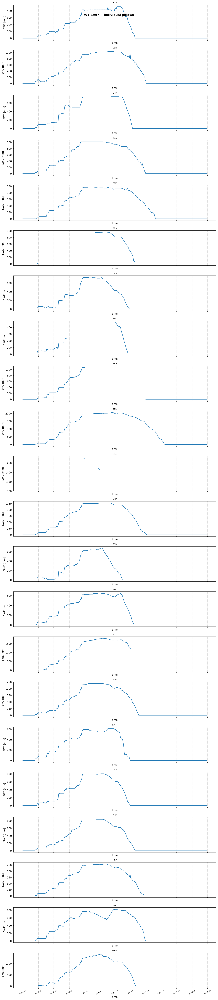

In [63]:
# obs data.
obs_data = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa5.nc')
inspect_water_years(obs_data, [1997],
                    pred_df=pred_df_v5_mm, pils_df=pred_df_v5_pillows,
                    aso_tseries_ds=aso_tseries_ds, version=1,elev_label='Basin') 


==================================================  WY 1997  ==================================================


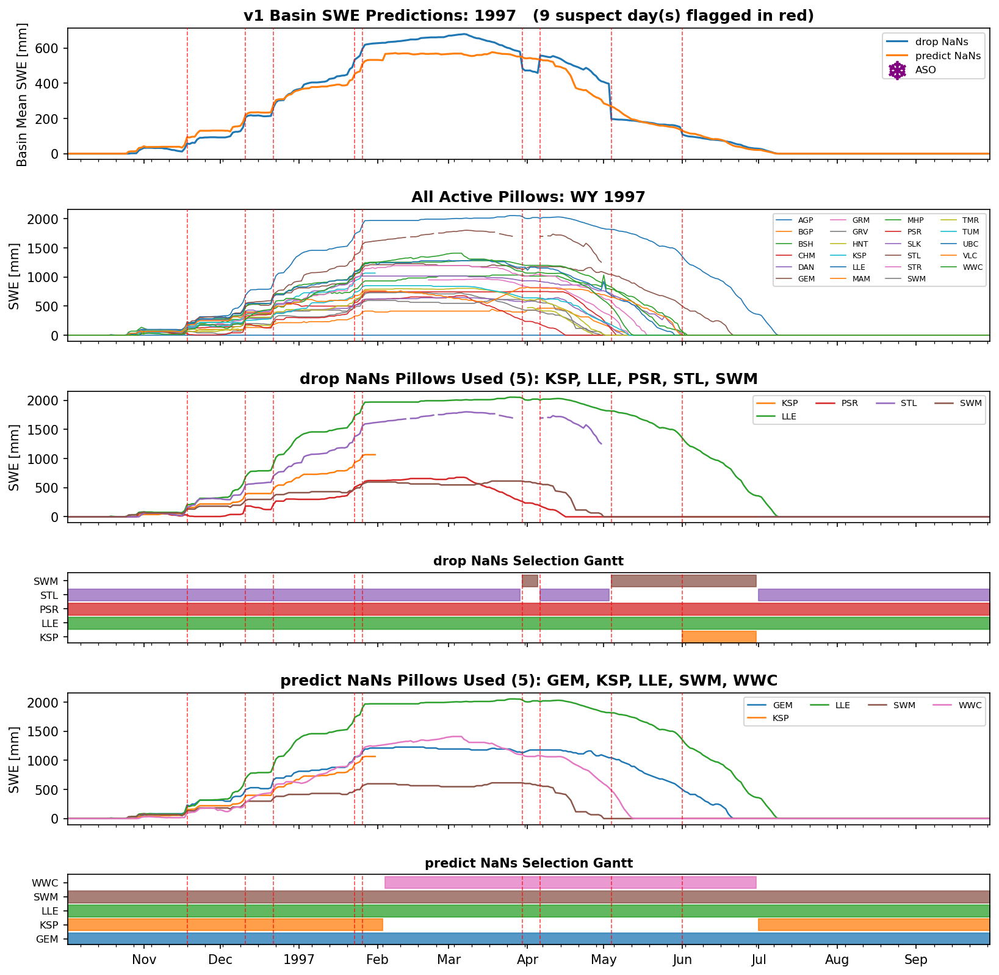

  suspect dates (|Δ| > 40 mm/day): 1996-11-18, 1996-12-11, 1996-12-22, 1997-01-23, 1997-01-26, 1997-03-30, 1997-04-06, 1997-05-04, 1997-06-01


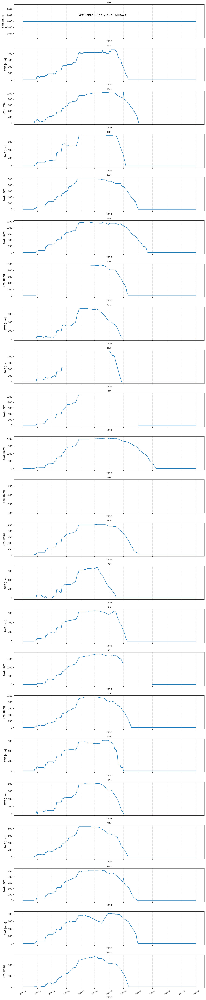

In [64]:
# obs data.
obs_data = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
inspect_water_years(obs_data, [1997],
                    pred_df=pred_df_v5_mm, pils_df=pred_df_v5_pillows,
                    aso_tseries_ds=aso_tseries_ds, version=1,elev_label='Basin') 

# Linear Interpolation (v3)

Fill short NaN gaps in `qa2.nc` with linear interpolation to prevent MLR
model-swap artifacts on brief sensor outages.

- Only fills gaps **≤ MAX_GAP_DAYS** (default 3)
- Only fills **bracketed** gaps (`limit_area='inside'`) — leading/trailing NaNs
  are untouched (no fabricating values before a pillow comes online or after
  it retires)
- Long gaps (sustained outages, manual exclusion windows) are untouched
- Writes:
  - `pillow_wy_1980_2025_qa3.nc` — the imputed dataset
  - `qa3_imputation_log.csv` — one row per imputed (pillow, date, value)


In [ ]:
# v3: linear-interpolate short bracketed NaN gaps in qa2.nc -> qa3.nc
# tweakable: MAX_GAP_DAYS controls the longest gap that gets filled.
import copy

MAX_GAP_DAYS = 3

qa2_path     = f'{insitu_dir}processed/pillow_wy_1980_2025_qa2.nc'
qa3_path     = f'{insitu_dir}processed/pillow_wy_1980_2025_qa3.nc'
imp_log_path = f'{insitu_dir}processed/qa3_imputation_log.csv'

ds_qa2 = xr.load_dataset(qa2_path)
ds_qa3 = copy.deepcopy(ds_qa2)

log_rows = []
for pil in ds_qa3.data_vars:
    s = ds_qa3[pil].to_series()
    if s.notna().sum() == 0:
        continue  # all-NaN pillow — nothing to do
    was_nan = s.isna()
    filled = s.interpolate(method='linear', limit=MAX_GAP_DAYS, limit_area='inside')
    newly_filled = was_nan & filled.notna()
    if newly_filled.any():
        for ts, val in filled[newly_filled].items():
            log_rows.append({
                'pillow':   pil,
                'date':     ts.strftime('%Y-%m-%d'),
                'value_mm': float(val),
            })
    # write back into the dataset (preserves attrs)
    ds_qa3[pil].values[:] = filled.values

log_df = pd.DataFrame(log_rows, columns=['pillow', 'date', 'value_mm'])
log_df.to_csv(imp_log_path, index=False)
ds_qa3.to_netcdf(qa3_path)

print(f'wrote {qa3_path}')
print(f'wrote {imp_log_path}  ({len(log_df):,} values imputed across {log_df["pillow"].nunique()} pillows)')
if len(log_df):
    print('\ntop 10 pillows by # of imputed values:')
    print(log_df['pillow'].value_counts().head(10).to_string())


# Fill Zero (v5)

In [26]:
# v5: zero-fill shoulder NaN gaps in qa3.nc -> qa5.nc
#
# Processes each pillow x water-year independently:
#   - SKIP the WY entirely if the pillow saw no real snow (max < SNOW_THRESHOLD)
#     -- protects against pillows that read 0 all year because they were broken
#   - LEADING gap (Oct 1 -> first valid date): fill with 0 iff first_val < ZERO_THRESHOLD_ACCUM
#   - TRAILING gap (last valid date -> Sep 30): handled in 3 cases:
#       (a) last_val < ZERO_THRESHOLD_ACCUM: already at zero, fill the tail with 0
#       (b) prior melt rate <= -MIN_MELT_RATE and projected days_to_zero <= MAX_EXTRAPOLATION:
#           linearly interp last_val -> 0 over `days_to_zero`, then 0 thereafter
#       (c) otherwise: leave NaN (pillow died with snow on it; can't extrapolate safely)
#
# Interior NaN gaps are left untouched (qa3 already handled short ones via linear interp).
import copy

# ---- tunable parameters ----
ZERO_THRESHOLD_ACCUM = 5.0   # mm; boundary value at-or-below this counts as "zero"
SNOW_THRESHOLD       = 50.0  # mm; WY max must reach this to trust any zero-fill for that WY
MELT_WINDOW          = 14    # days; calendar window before last_date used to fit melt rate
MIN_VALID_FOR_RATE   = 5     # need at least this many valid obs in MELT_WINDOW to compute rate
MIN_MELT_RATE        = 2.0   # mm/day; |slope| must exceed this (and be negative) to extrapolate
MAX_EXTRAPOLATION    = 15    # days; refuse to project melt-to-zero further than this

qa3_path     = f'{insitu_dir}processed/pillow_wy_1980_2025_qa3.nc'
qa5_path     = f'{insitu_dir}processed/pillow_wy_1980_2025_qa5.nc'
log_path     = f'{insitu_dir}processed/qa5_zerofill_log.csv'

ds_qa3 = xr.load_dataset(qa3_path)
ds_qa5 = copy.deepcopy(ds_qa3)

# build (water_year -> [start_ts, end_ts]) index once
times_idx = pd.DatetimeIndex(ds_qa5.time.values)
wy_of = np.where(times_idx.month >= 10, times_idx.year + 1, times_idx.year)
wys = sorted(set(wy_of.tolist()))

log_rows = []
for pil in ds_qa5.data_vars:
    s_full = ds_qa5[pil].to_series()
    if s_full.notna().sum() == 0:
        continue  # all-NaN pillow

    for wy in wys:
        wy_start = pd.Timestamp(f'{wy-1}-10-01')
        wy_end   = pd.Timestamp(f'{wy}-09-30')
        s = s_full.loc[wy_start:wy_end]
        if len(s) == 0:
            continue

        valid = s.dropna()
        if len(valid) == 0:
            continue

        wy_max = float(valid.max())
        if wy_max < SNOW_THRESHOLD:
            # saw-snow guard: pillow never accumulated meaningful snow this WY
            continue

        first_date, first_val = valid.index[0], float(valid.iloc[0])
        last_date,  last_val  = valid.index[-1], float(valid.iloc[-1])

        # ---- LEADING gap ----
        if first_date > wy_start and first_val < ZERO_THRESHOLD_ACCUM:
            lead_idx = s.loc[wy_start:first_date - pd.Timedelta(days=1)].index
            lead_idx = lead_idx[s.loc[lead_idx].isna()]
            if len(lead_idx) > 0:
                s_full.loc[lead_idx] = 0.0
                log_rows.append({
                    'pillow':       pil,
                    'water_year':   wy,
                    'gap_type':     'leading',
                    'gap_start':    lead_idx.min().strftime('%Y-%m-%d'),
                    'gap_end':      lead_idx.max().strftime('%Y-%m-%d'),
                    'n_days_filled': int(len(lead_idx)),
                    'boundary_val_mm': round(first_val, 2),
                    'melt_rate_mm_per_day': None,
                    'extrapolation_days': None,
                    'wy_max_mm':    round(wy_max, 1),
                })

        # ---- TRAILING gap ----
        if last_date < wy_end:
            trail_idx = s.loc[last_date + pd.Timedelta(days=1):wy_end].index
            trail_idx = trail_idx[s.loc[trail_idx].isna()]
            if len(trail_idx) == 0:
                continue

            # (a) already at zero
            if last_val < ZERO_THRESHOLD_ACCUM:
                s_full.loc[trail_idx] = 0.0
                log_rows.append({
                    'pillow':       pil,
                    'water_year':   wy,
                    'gap_type':     'trailing_zero',
                    'gap_start':    trail_idx.min().strftime('%Y-%m-%d'),
                    'gap_end':      trail_idx.max().strftime('%Y-%m-%d'),
                    'n_days_filled': int(len(trail_idx)),
                    'boundary_val_mm': round(last_val, 2),
                    'melt_rate_mm_per_day': None,
                    'extrapolation_days': None,
                    'wy_max_mm':    round(wy_max, 1),
                })
                continue

            # (b) try melt extrapolation
            rate_window_start = last_date - pd.Timedelta(days=MELT_WINDOW - 1)
            rate_obs = s.loc[rate_window_start:last_date].dropna()
            if len(rate_obs) < MIN_VALID_FOR_RATE:
                continue  # not enough data for a stable rate

            # linear fit: x = days-from-window-start, y = value (mm)
            x = (rate_obs.index - rate_window_start).days.values.astype(float)
            y = rate_obs.values.astype(float)
            slope, _ = np.polyfit(x, y, 1)  # mm per day
            if slope > -MIN_MELT_RATE:
                continue  # not melting (or not fast enough) -- leave NaN

            days_to_zero = last_val / abs(slope)
            if days_to_zero > MAX_EXTRAPOLATION:
                continue  # gap to zero too long to trust

            # build extrapolated values for the dates following last_date
            extrap_end_date = last_date + pd.Timedelta(days=int(np.ceil(days_to_zero)))
            # cap extrapolation at the WY end
            extrap_end_date = min(extrap_end_date, wy_end)
            extrap_idx = pd.date_range(last_date + pd.Timedelta(days=1),
                                       extrap_end_date, freq='D')
            # linear from last_val -> 0
            for i, d in enumerate(extrap_idx, start=1):
                v = max(0.0, last_val + slope * i)
                if d in trail_idx:  # only fill where originally NaN
                    s_full.loc[d] = v
            # then zero-fill the rest of the trailing run (after extrapolation finishes)
            post_zero_idx = trail_idx[trail_idx > extrap_end_date]
            if len(post_zero_idx) > 0:
                s_full.loc[post_zero_idx] = 0.0

            n_filled = int(len(trail_idx))  # everything in trail_idx is now filled
            log_rows.append({
                'pillow':       pil,
                'water_year':   wy,
                'gap_type':     'trailing_melt_extrap',
                'gap_start':    trail_idx.min().strftime('%Y-%m-%d'),
                'gap_end':      trail_idx.max().strftime('%Y-%m-%d'),
                'n_days_filled': n_filled,
                'boundary_val_mm': round(last_val, 2),
                'melt_rate_mm_per_day': round(float(slope), 3),
                'extrapolation_days': round(float(days_to_zero), 1),
                'wy_max_mm':    round(wy_max, 1),
            })

    # write modified series back to dataset (preserves attrs)
    ds_qa5[pil].values[:] = s_full.values

log_df = pd.DataFrame(log_rows, columns=[
    'pillow', 'water_year', 'gap_type', 'gap_start', 'gap_end',
    'n_days_filled', 'boundary_val_mm', 'melt_rate_mm_per_day',
    'extrapolation_days', 'wy_max_mm',
])
log_df.to_csv(log_path, index=False)
ds_qa5.to_netcdf(qa5_path)

print(f'wrote {qa5_path}')
print(f'wrote {log_path}  ({len(log_df):,} fill action(s) across '
      f'{log_df["pillow"].nunique() if len(log_df) else 0} pillows, '
      f'{log_df["water_year"].nunique() if len(log_df) else 0} WYs)')
if len(log_df):
    total_days = int(log_df['n_days_filled'].sum())
    print(f'\ntotal NaN cells zero-filled: {total_days:,}')
    print('\nbreakdown by gap_type:')
    print(log_df.groupby('gap_type')['n_days_filled'].agg(['count', 'sum']).to_string())
    print('\ntop 10 pillows by # of cells filled:')
    print(log_df.groupby('pillow')['n_days_filled'].sum().sort_values(ascending=False).head(10).to_string())


wrote /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa5.nc
wrote /home/rossamower/work/aso/data/insitu/FRIANT/processed/qa5_zerofill_log.csv  (220 fill action(s) across 26 pillows, 34 WYs)

total NaN cells zero-filled: 14,524

breakdown by gap_type:
                      count   sum
gap_type                         
leading                 123  3158
trailing_melt_extrap     21  2759
trailing_zero            76  8607

top 10 pillows by # of cells filled:
pillow
PSR    1620
TUM    1545
TMR    1355
SLK    1292
KSP    1185
DAN    1134
GRM    1003
WWC     870
GRV     801
MAM     786


## v6

In [38]:
def multi_elev_overview(pred_df, pils_df, aso_tseries_ds, water_year,
                        elev_labels=None, include_basin=True, show_basin_aso=True):
    """
    Two-panel overview of v* predictions across all elevation bands for one WY.

      Top:    drop NaNs predictions, one line per elevation band
      Bottom: predict NaNs predictions, same coloring

    Optional ASO basin-total scatter overlay on both panels (for ground-truth
    reference at flight dates).
    """
    if elev_labels is None:
        elev_labels = ['<7k', '7k-8k', '8k-9k', '9k-10k', '10k-11k', '11k-12k', '>12k']
        if include_basin:
            elev_labels = elev_labels + ['Basin']

    pred_wy = pred_df[pred_df['Wateryear'] == water_year]
    drop_pred    = pred_wy[pred_wy['Training Infer NaNs'] == 'drop NaNs'].copy().sort_values('Date')
    predict_pred = pred_wy[pred_wy['Training Infer NaNs'] == 'predict NaNs'].copy().sort_values('Date')

    # color per elev: viridis ramp for elev bands, black for Basin
    cmap = plt.get_cmap('viridis')
    bands_only = [e for e in elev_labels if e != 'Basin']
    colors = {}
    for i, e in enumerate(bands_only):
        colors[e] = cmap(i / max(1, len(bands_only) - 1))
    if 'Basin' in elev_labels:
        colors['Basin'] = 'black'

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), dpi=150, sharex=True)
    for elev in elev_labels:
        if elev not in drop_pred.columns:
            continue
        lw = 1.6 if elev == 'Basin' else 1.0
        if len(drop_pred):
            axes[0].plot(drop_pred['Date'], drop_pred[elev],
                         label=elev, color=colors[elev], linewidth=lw)
        if len(predict_pred):
            axes[1].plot(predict_pred['Date'], predict_pred[elev],
                         label=elev, color=colors[elev], linewidth=lw)

    if show_basin_aso:
        aso_slice = aso_tseries_ds.where(aso_tseries_ds.date.dt.year == water_year)
        basin_aso = aso_slice.aso_swe.sel(elev='total').values
        for ax in axes:
            ax.scatter(aso_slice.date.values, basin_aso,
                       marker=u'$❄$', s=180, color='purple', label='ASO (Basin)')

    axes[0].set_title(f'WY {water_year} -- drop NaNs predictions across elevation bands',
                      fontweight='bold')
    axes[1].set_title(f'WY {water_year} -- predict NaNs predictions across elevation bands',
                      fontweight='bold')
    for ax in axes:
        ax.set_ylabel('SWE [mm]')
        ax.legend(loc='upper right', ncols=2, fontsize=7)
        _add_date_grid(ax)
    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()


def manual_pillow_qa_v6(obs_data1,
                        obs_data5,
                        pred_df,
                        pils_df,
                        aso_tseries_ds,
                        water_years,
                        model_type='predict NaNs',
                        version=6,
                        resume=True,
                        qa_nc_path=None,
                        qa_log_path=None,
                        reviewed_path=None,
                        logMode=True):
    """
    v6 multi-elevation manual QA orchestrator.

    For each water year:
      1. Render `multi_elev_overview` (top: drop NaNs; bottom: predict NaNs;
         one line per elevation band, with optional ASO basin scatter).
      2. Prompt: "Investigate WY {wy}?"
      3. If yes: loop, asking which elevation band to focus on. For each
         chosen band, call `manual_pillow_qa` with the relevant elev_label
         and an obs_data_overlay=[(obs_data1, 'v1', 'C7')] so each
         individual pillow plot shows v5 (solid) and v1 (dashed) for
         processing-artifact comparison. Loop until user types 'done'.
      4. Mark WY reviewed in v6's own reviewed_years CSV.

    Outputs under {insitu_dir}processed/ (override via kwargs):
      - pillow_wy_1980_2025_qa6.nc       : the masked dataset (init from qa5)
      - manual_qa_log_v6.csv              : one row per (pil, range) removed
      - manual_qa_reviewed_years_v6.csv   : years marked done

    The inner manual_pillow_qa call uses `mark_reviewed=False` so this
    orchestrator solely controls v6 reviewed-state.

    logMode : bool
        When True (default), all changes are persisted to disk (qa6.nc,
        qa6 log CSV, v6 reviewed-years CSV) -- and the inner manual_pillow_qa
        call also writes. When False, runs in DRY-RUN mode: plots/prompts
        happen, in-memory modifications are made, but nothing is written.
        Existing v6 files on disk are still READ for the resume / state
        starting point. Useful for previewing without side effects.
    """
    import copy, os

    base = f'{insitu_dir}processed/'
    if qa_nc_path is None:
        qa_nc_path = f'{base}pillow_wy_1980_2025_qa6.nc'
    if qa_log_path is None:
        qa_log_path = f'{base}manual_qa_log_v6.csv'
    if reviewed_path is None:
        reviewed_path = f'{base}manual_qa_reviewed_years_v6.csv'

    if not logMode:
        print('*** DRY-RUN MODE (logMode=False): plots/prompts run, '
              'but NO .nc/.csv writes will occur. ***')

    # initialize qa6.nc from obs_data5 if not present (skipped in dry mode)
    if logMode and not os.path.exists(qa_nc_path):
        print(f'Initializing {qa_nc_path} from qa5 (deep copy)')
        copy.deepcopy(obs_data5).to_netcdf(qa_nc_path)

    # load v6 reviewed_years (separate from v2's)
    if resume and os.path.exists(reviewed_path):
        reviewed_years = set(int(y) for y in pd.read_csv(reviewed_path)['water_year'].tolist())
        print(f'Already-reviewed years in v6: {sorted(reviewed_years)}')
    else:
        reviewed_years = set()

    def _persist_reviewed():
        if not logMode:
            return
        pd.DataFrame({'water_year': sorted(reviewed_years)}).to_csv(reviewed_path, index=False)

    elev_choices = ['<7k', '7k-8k', '8k-9k', '9k-10k', '10k-11k', '11k-12k', '>12k', 'Basin']

    try:
        for wy in water_years:
            if wy in reviewed_years:
                print(f'  WY {wy}: already reviewed in v6 -- skipping. '
                      f'(Remove {wy} from {reviewed_path} or pass resume=False to redo.)')
                continue

            print(f"\n{'='*50}  WY {wy}  --  multi-elev overview  {'='*50}")
            multi_elev_overview(pred_df, pils_df, aso_tseries_ds, wy)

            try:
                investigate = bool(int(input(f'Investigate WY {wy}? [Yes=1 / No=0]: ')))
            except ValueError:
                print('  Invalid input, defaulting to No.')
                investigate = False

            if not investigate:
                reviewed_years.add(wy)
                _persist_reviewed()
                print(f'  WY {wy}: marked reviewed (no investigation).')
                continue

            # elev drilldown loop
            while True:
                print(f"  Elevation choices: {elev_choices + ['done']}")
                elev = input("  Which elevation to investigate? (or 'done' to finalize this WY): ").strip()
                if elev.lower() == 'done':
                    break
                if elev not in elev_choices:
                    print(f"  '{elev}' not recognized. Try again.")
                    continue

                # delegate to manual_pillow_qa with v6 paths + elev focus + v1 overlay
                manual_pillow_qa(
                    obs_data_ds=obs_data5,         # only used if qa6.nc didn't exist; safety net
                    pred_df=pred_df,
                    pils_df=pils_df,
                    aso_tseries_ds=aso_tseries_ds,
                    water_years=[wy],
                    model_type=model_type,
                    version=version,
                    resume=True,
                    qa_nc_path=qa_nc_path,
                    qa_log_path=qa_log_path,
                    reviewed_path=reviewed_path,
                    elev_label=elev,
                    obs_data_overlay=[(obs_data1, 'v1', 'black')],
                    mark_reviewed=False,
                    logMode=logMode,
                )

            reviewed_years.add(wy)
            _persist_reviewed()
            print(f'  WY {wy}: complete, marked reviewed in v6.')

    except KeyboardInterrupt:
        print('\nInterrupted -- saving v6 progress.')
        _persist_reviewed()
        raise
    finally:
        _persist_reviewed()

    # final read-back: only meaningful in logMode (the disk reflects the run).
    # In dry mode, return whatever's on disk (unchanged) so caller can compare.
    if os.path.exists(qa_nc_path):
        obs_data_qa6 = xr.load_dataset(qa_nc_path)
    else:
        obs_data_qa6 = obs_data5
    qa_log_df = pd.read_csv(qa_log_path) if os.path.exists(qa_log_path) else pd.DataFrame()
    return obs_data_qa6, qa_log_df


Already-reviewed years in v6: [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  WY 1980: already reviewed in v6 -- skipping. (Remove 1980 from /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years_v6.csv or pass resume=False to redo.)
  WY 1981: already reviewed in v6 -- skipping. (Remove 1981 from /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years_v6.csv or pass resume=False to redo.)
  WY 1982: already reviewed in v6 -- skipping. (Remove 1982 from /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years_v6.csv or pass resume=False to redo.)
  WY 1983: already reviewed in v6 -- skipping. (Remove 1983 from /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years_v6.cs

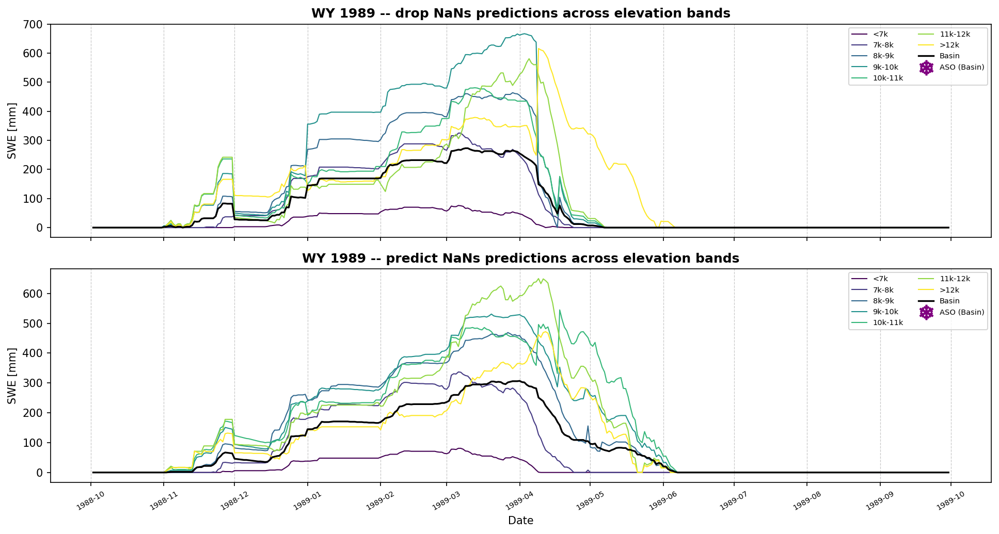

  Elevation choices: ['<7k', '7k-8k', '8k-9k', '9k-10k', '10k-11k', '11k-12k', '>12k', 'Basin', 'done']
Resuming from /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa6.nc
Loaded 101 prior removal(s) from log.
Already-reviewed years (will skip): [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

==================================================  WY 1989  (10k-11k)  ==================================================


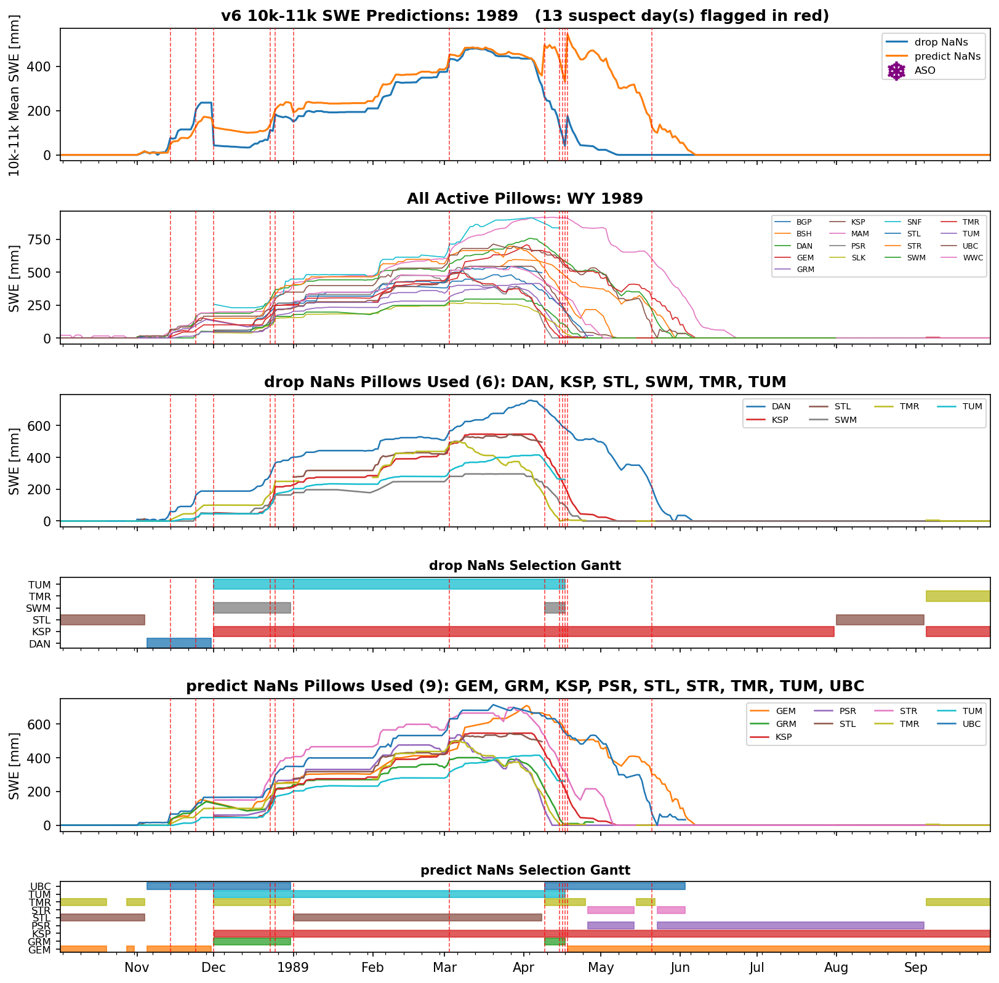

  suspect dates (|Δ| > 40 mm/day): 1988-11-14, 1988-11-24, 1988-12-01, 1988-12-23, 1988-12-25, 1989-01-01, 1989-03-03, 1989-04-09, 1989-04-15, 1989-04-16, 1989-04-17, 1989-04-18, 1989-05-21


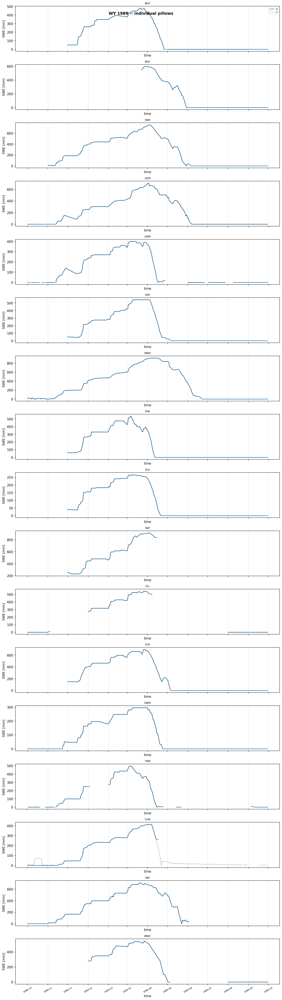

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


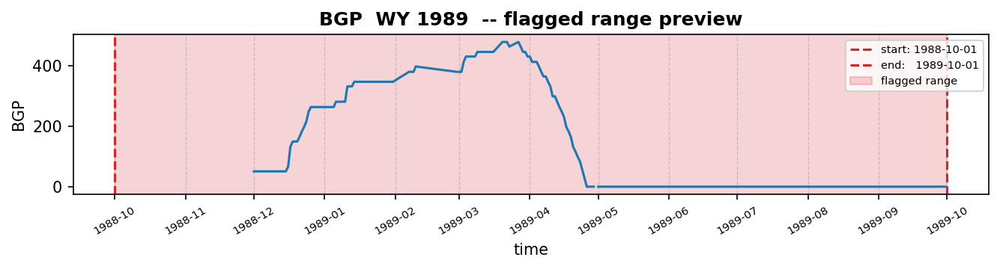

    Nulled 366 values for BGP (1988-10-01 to 1989-10-01); saved.


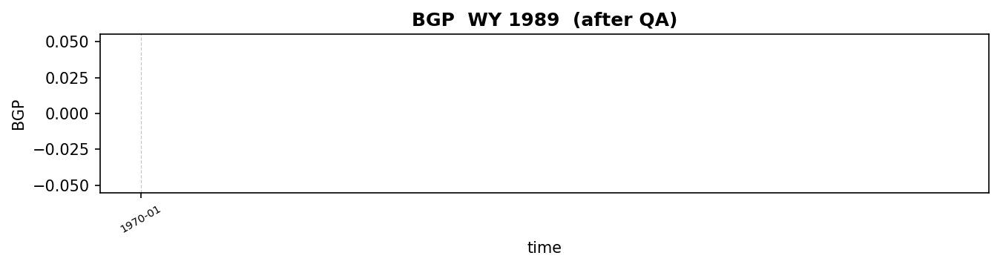

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


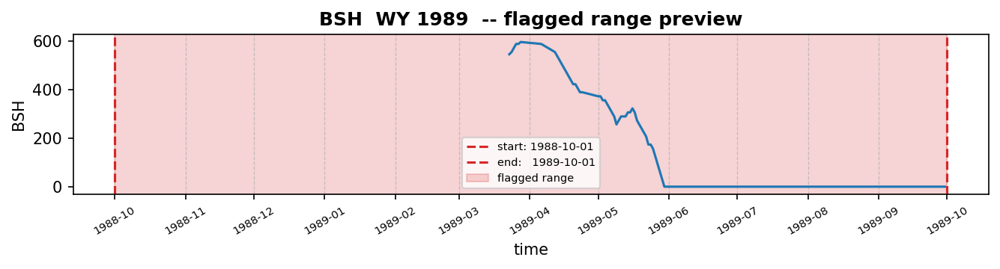

    Nulled 366 values for BSH (1988-10-01 to 1989-10-01); saved.


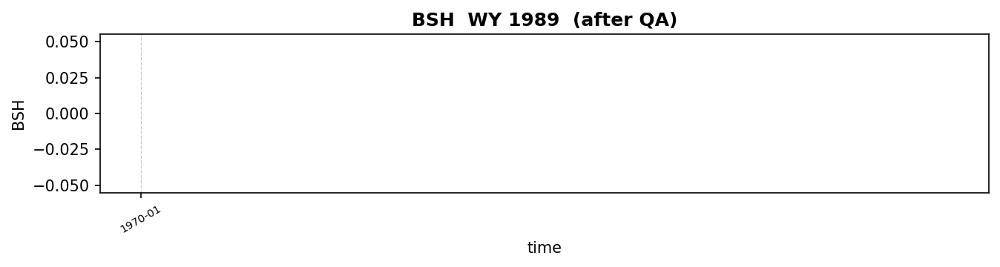

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


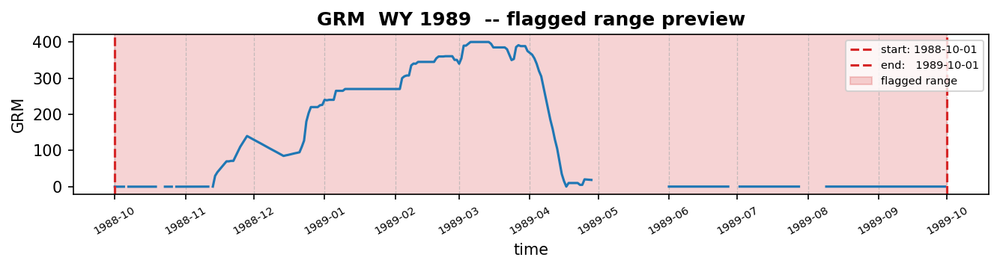

    Nulled 366 values for GRM (1988-10-01 to 1989-10-01); saved.


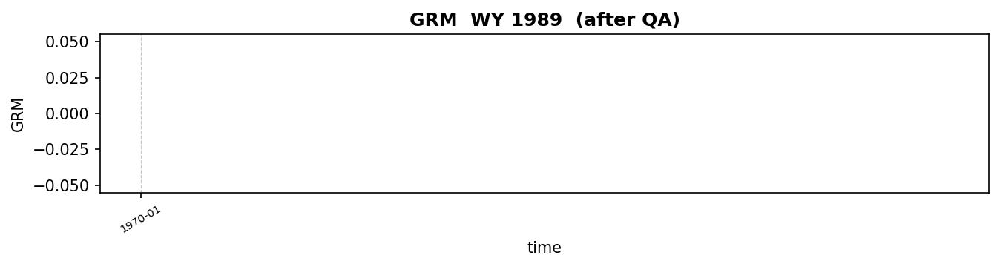

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


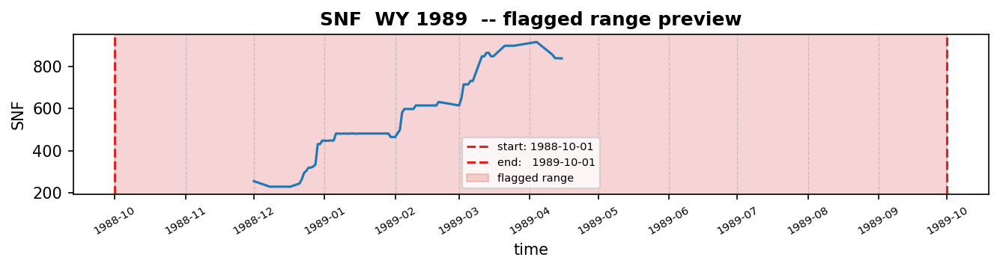

    Nulled 366 values for SNF (1988-10-01 to 1989-10-01); saved.


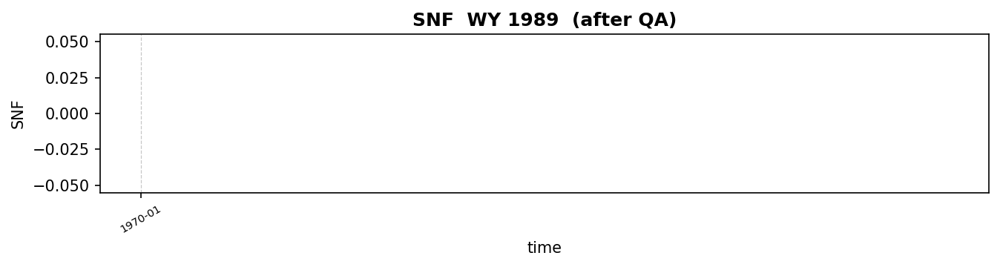

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


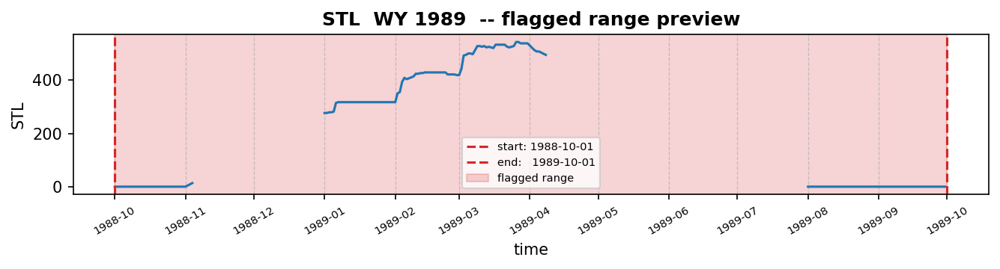

    Nulled 366 values for STL (1988-10-01 to 1989-10-01); saved.


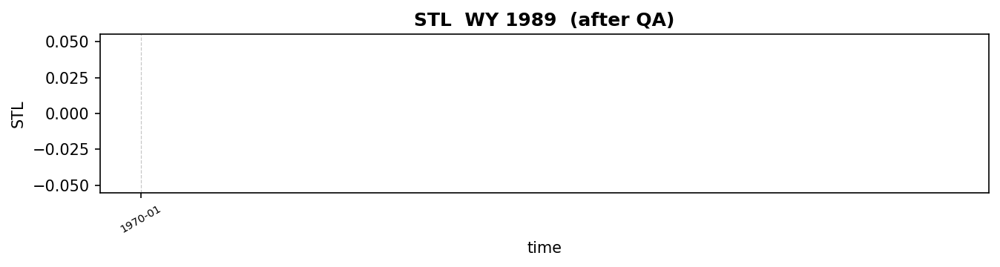

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


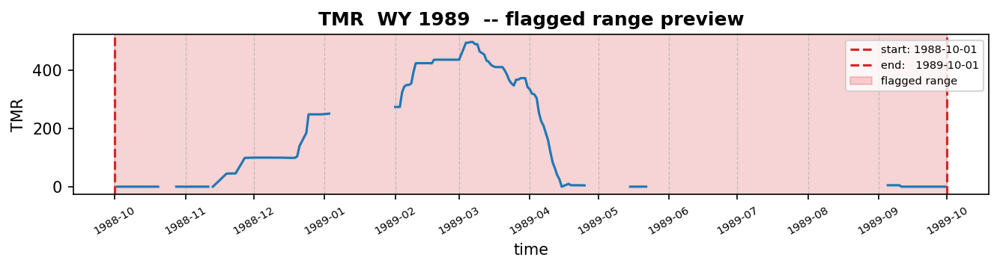

    Nulled 366 values for TMR (1988-10-01 to 1989-10-01); saved.


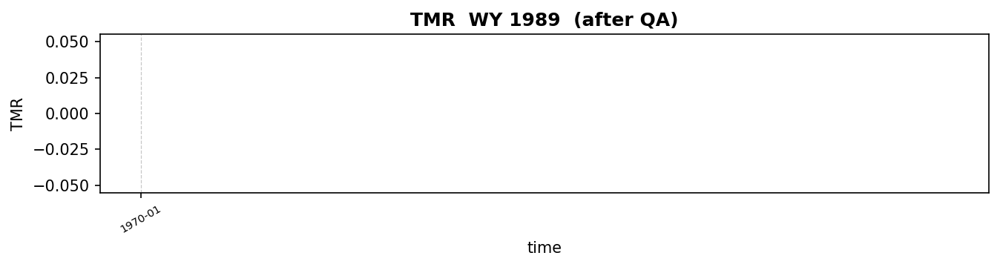

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']


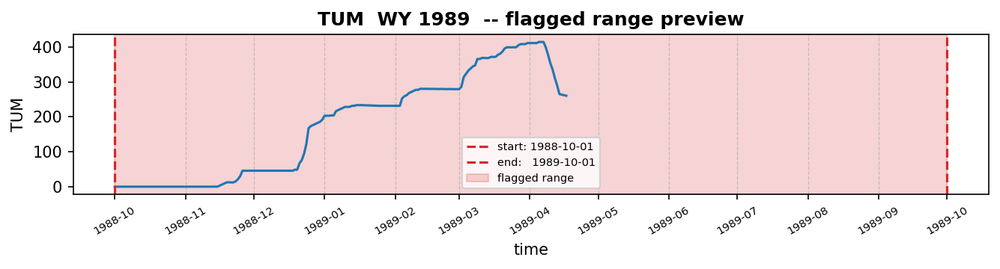

    Nulled 366 values for TUM (1988-10-01 to 1989-10-01); saved.


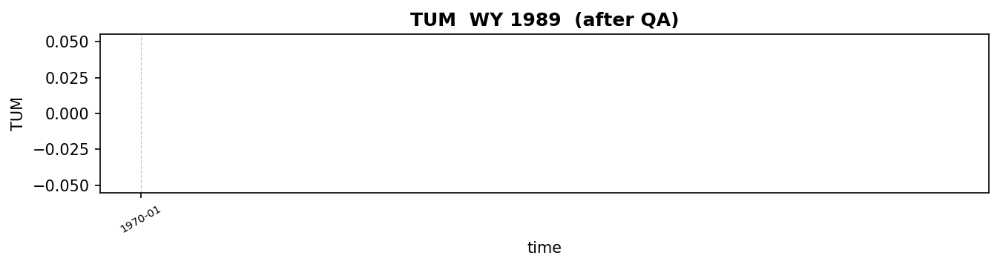

  Active pillows: ['BGP', 'BSH', 'DAN', 'GEM', 'GRM', 'KSP', 'MAM', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'WWC']
  WY 1989: pass complete, state saved.

-- QA Log --
 water_year pillow      start        end  n_values_removed
       1980    KSP 1980-02-01 1980-03-01                30
       1981    KSP 1980-10-01 1981-10-01               366
       1984    GRM 1984-05-07 1984-10-01               148
       1985    GRM 1985-05-04 1985-10-01               151
       1986    SLK 1985-10-01 1986-10-01               366
       1986    MAM 1985-10-01 1986-10-01               366
       1987    STL 1986-10-01 1987-10-01               366
       1988    BSH 1987-10-01 1988-10-01               367
       1988    PSR 1987-10-01 1988-10-01               367
       1988    SLK 1987-10-01 1988-10-01               367
       1988    TMR 1987-10-01 1988-10-01               367
       1990    SWM 1989-10-01 1990-10-01               366
       1990    BCB 1989-10-01 1990-10-01  

In [39]:

start_wy = 1980
end_wy = 2025
water_years = list(range(start_wy, end_wy + 1))
obs_data5 = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa5.nc')
obs_data1 = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')

# preview run.
# obs_data_v6_preview, qa_log_preview = manual_pillow_qa_v6(
#     obs_data1, obs_data5, pred_df_v5_mm, pred_df_v5_pillows,
#     aso_tseries_ds, water_years, logMode=False,
# )
# real run
obs_data_qa, qa_log_df = manual_pillow_qa_v6(
    obs_data1, obs_data5, pred_df_v5_mm, pred_df_v5_pillows,
    aso_tseries_ds, water_years,  # logMode defaults to True
)


# obs_data_qa, qa_log_df = manual_pillow_qa_v6(
#     obs_data1,
#     obs_data5,
#     pred_df_v5_mm,
#     pred_df_v5_pillows,
#     aso_tseries_ds,
#     water_years,
#     model_type='predict NaNs',
#     version=6,
# )

# Surgical Edits to get WY 1997 in v2-v5

In [52]:
# Step A: splice WY 1997 from qa1.nc into qa2.nc AND un-review WY 1997
# in the manual_qa_reviewed_years.csv. Backs up qa2.nc to qa2.nc.bak and
# the reviewed CSV to .bak first. Defensive: drops any existing 1997
# dates from qa2 before splicing. Non-1997 data is preserved.
#
# Why the un-review: when the original manual_pillow_qa run iterated to
# WY 1997, qa2 had no 1997 dates so it auto-marked 1997 as "reviewed"
# (no active pillows). That entry blocks Step B until removed.
import shutil

WY = 1997
wy_start = np.datetime64(f'{WY-1}-10-01')
wy_end   = np.datetime64(f'{WY}-10-01')

qa1_path      = f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc'
qa2_path      = f'{insitu_dir}processed/pillow_wy_1980_2025_qa2.nc'
reviewed_path = f'{insitu_dir}processed/manual_qa_reviewed_years.csv'

# ---- splice 1997 from qa1 into qa2 ----
shutil.copy(qa2_path, qa2_path + '.bak')
print(f'backed up {qa2_path} -> {qa2_path}.bak')

ds_qa1 = xr.load_dataset(qa1_path)
ds_qa2 = xr.load_dataset(qa2_path)

qa2_clean = ds_qa2.where(
    (ds_qa2.time < wy_start) | (ds_qa2.time >= wy_end), drop=True)
qa1_wy = ds_qa1.where(
    (ds_qa1.time >= wy_start) & (ds_qa1.time < wy_end), drop=True)

ds_qa2_new = xr.concat([qa2_clean, qa1_wy], dim='time').sortby('time')

print(f'qa2 before: {len(ds_qa2.time)} time entries  |  '
      f'after splice: {len(ds_qa2_new.time)} entries  '
      f'(+{len(ds_qa2_new.time) - len(ds_qa2.time)} from WY {WY})')

ds_qa2_new.to_netcdf(qa2_path)
print(f'wrote {qa2_path}')

# ---- un-review WY 1997 in the reviewed CSV ----
shutil.copy(reviewed_path, reviewed_path + '.bak')
print(f'backed up {reviewed_path} -> {reviewed_path}.bak')

reviewed_df = pd.read_csv(reviewed_path)
before = len(reviewed_df)
reviewed_df = reviewed_df[reviewed_df['water_year'] != WY]
after = len(reviewed_df)
reviewed_df.to_csv(reviewed_path, index=False)
print(f'reviewed_years CSV: {before} -> {after} entries '
      f'({"WY %d removed" % WY if before != after else "WY %d not present, no change" % WY})')


backed up /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa2.nc -> /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa2.nc.bak
qa2 before: 16803 time entries  |  after splice: 16803 entries  (+0 from WY 1997)
wrote /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa2.nc
backed up /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years.csv -> /home/rossamower/work/aso/data/insitu/FRIANT/processed/manual_qa_reviewed_years.csv.bak
reviewed_years CSV: 46 -> 45 entries (WY 1997 removed)


Resuming from /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa2.nc
Loaded 68 prior removal(s) from log.
Already-reviewed years (will skip): [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

==================================================  WY 1997  ==================================================


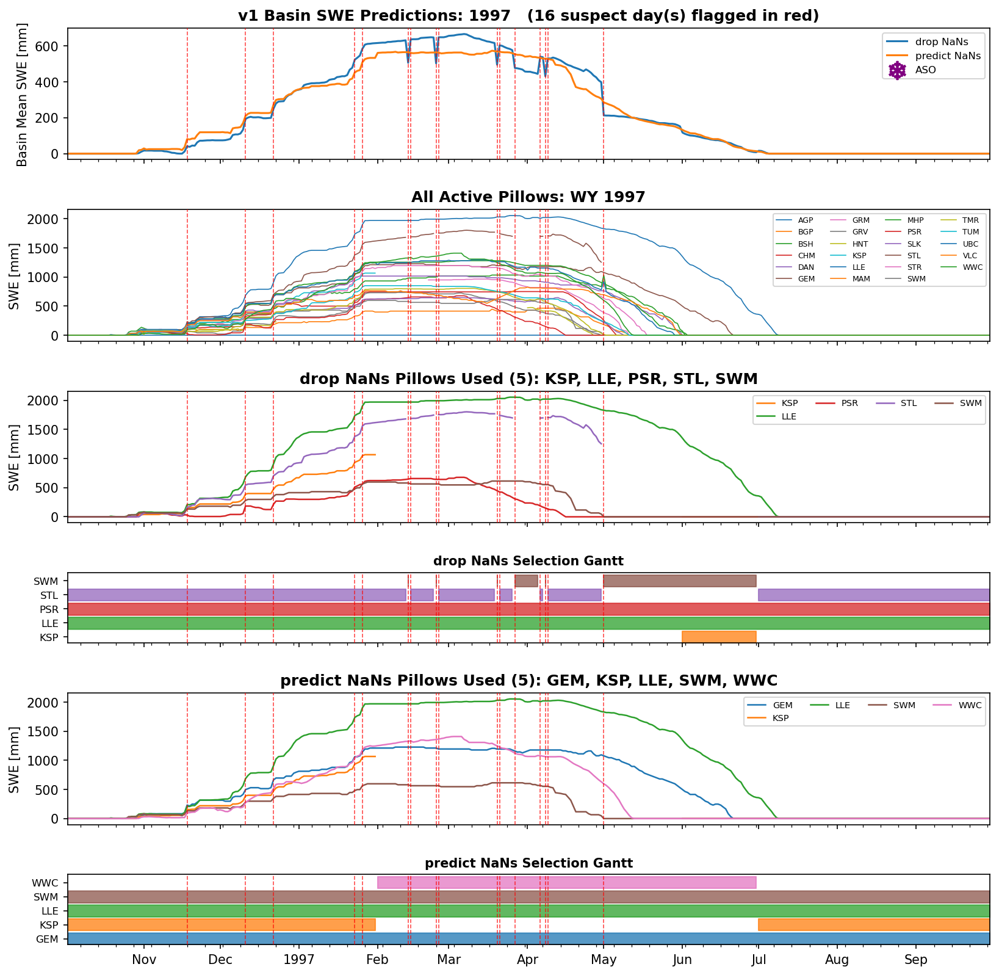

  suspect dates (|Δ| > 40 mm/day): 1996-11-18, 1996-12-11, 1996-12-22, 1997-01-23, 1997-01-26, 1997-02-13, 1997-02-14, 1997-02-24, 1997-02-25, 1997-03-20, 1997-03-21, 1997-03-27, 1997-04-06, 1997-04-08, 1997-04-09, 1997-05-01


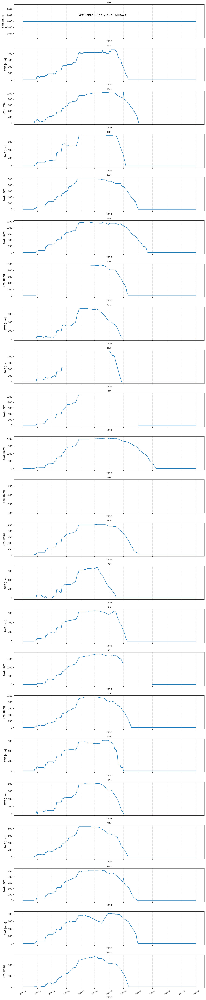

  Active pillows: ['AGP', 'BGP', 'BSH', 'CHM', 'DAN', 'GEM', 'GRM', 'GRV', 'HNT', 'KSP', 'LLE', 'MAM', 'MHP', 'PSR', 'SLK', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'VLC', 'WWC']


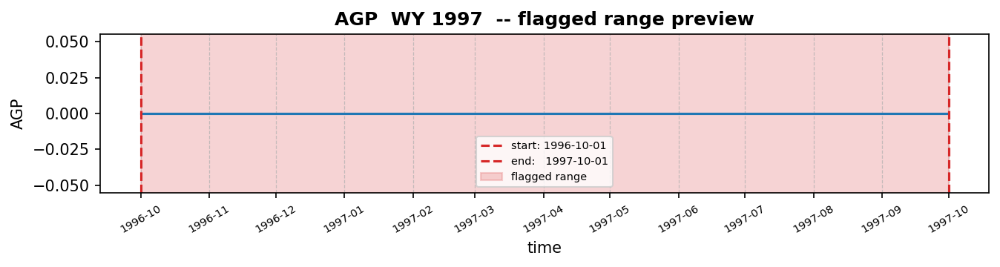

    Nulled 366 values for AGP (1996-10-01 to 1997-10-01); saved.


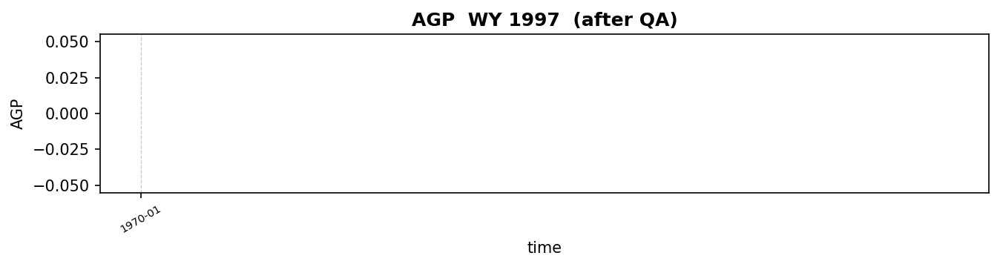

  Active pillows: ['AGP', 'BGP', 'BSH', 'CHM', 'DAN', 'GEM', 'GRM', 'GRV', 'HNT', 'KSP', 'LLE', 'MAM', 'MHP', 'PSR', 'SLK', 'STL', 'STR', 'SWM', 'TMR', 'TUM', 'UBC', 'VLC', 'WWC']
  WY 1997: complete, state saved.

-- QA Log --
 water_year pillow      start        end  n_values_removed
       1980    WWC 1979-10-01 1980-10-01               367
       1981    KSP 1981-04-01 1981-10-01               184
       1982    GRM 1981-10-01 1982-10-01               366
       1983    PSR 1982-10-01 1982-10-15                15
       1984    PSR 1984-04-15 1984-10-01               170
       1984    TMR 1984-04-15 1984-10-01               170
       1984    DAN 1984-06-01 1984-10-01               123
       1985    GRV 1984-10-01 1985-10-01               366
       1986    PSR 1986-05-01 1986-10-01               154
       1987    TUM 1987-04-20 1987-10-01               165
       1987    GRM 1986-10-01 1987-10-01               366
       1988    PSR 1988-03-15 1988-10-01               201
     

In [53]:
# Step B: run manual_pillow_qa for WY 1997 only.
# Resumes from the now-spliced qa2.nc (Step A must have been run). Only
# WY 1997 is iterated; the reviewed_years CSV protects all other years.
# Uncomment to run.

obs_data_qa, qa_log_df = manual_pillow_qa(
    obs_data_train_ds,           # ignored when resume=True and qa2.nc exists
    pred_df_v1_mm,
    pred_df_v1_pillows,
    aso_tseries_ds,
    water_years=[1997],
    model_type='predict NaNs',
    version=1,
    resume=True,
)


In [54]:
# Step C: surgical v3 -- apply linear interp to WY 1997 only and splice
# into existing qa3.nc. Backs up qa3.nc to qa3.nc.bak first.
import shutil
import copy

WY = 1997
wy_start = np.datetime64(f'{WY-1}-10-01')
wy_end   = np.datetime64(f'{WY}-10-01')

qa2_path = f'{insitu_dir}processed/pillow_wy_1980_2025_qa2.nc'
qa3_path = f'{insitu_dir}processed/pillow_wy_1980_2025_qa3.nc'

shutil.copy(qa3_path, qa3_path + '.bak')
print(f'backed up {qa3_path} -> {qa3_path}.bak')

ds_qa2 = xr.load_dataset(qa2_path)
ds_qa3_existing = xr.load_dataset(qa3_path)

# extract WY 1997 from qa2, apply linear interp to that slice only
qa2_wy = ds_qa2.where(
    (ds_qa2.time >= wy_start) & (ds_qa2.time < wy_end), drop=True)
qa3_wy = copy.deepcopy(qa2_wy)

MAX_GAP_DAYS = 3
log_rows = []
for pil in qa3_wy.data_vars:
    s = qa3_wy[pil].to_series()
    if s.notna().sum() == 0:
        continue
    was_nan = s.isna()
    filled = s.interpolate(method='linear', limit=MAX_GAP_DAYS, limit_area='inside')
    newly_filled = was_nan & filled.notna()
    if newly_filled.any():
        for ts, val in filled[newly_filled].items():
            log_rows.append({
                'pillow':   pil,
                'date':     ts.strftime('%Y-%m-%d'),
                'value_mm': float(val),
            })
    qa3_wy[pil].values[:] = filled.values

# defensive: drop any existing 1997 dates from qa3 (there shouldn't be any)
qa3_clean = ds_qa3_existing.where(
    (ds_qa3_existing.time < wy_start) | (ds_qa3_existing.time >= wy_end), drop=True)

ds_qa3_new = xr.concat([qa3_clean, qa3_wy], dim='time').sortby('time')

print(f'qa3 before: {len(ds_qa3_existing.time)} time entries  |  '
      f'after splice: {len(ds_qa3_new.time)} entries')
print(f'WY {WY} v3 interp: {len(log_rows)} value(s) filled')
if log_rows:
    log_df = pd.DataFrame(log_rows, columns=['pillow', 'date', 'value_mm'])
    print(log_df.head(20).to_string(index=False))

ds_qa3_new.to_netcdf(qa3_path)
print(f'wrote {qa3_path}')


backed up /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa3.nc -> /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa3.nc.bak
qa3 before: 16438 time entries  |  after splice: 16803 entries
WY 1997 v3 interp: 26 value(s) filled
pillow       date    value_mm
   GRM 1996-10-30    8.260522
   GRM 1996-10-31   16.521043
   GRM 1996-11-01   24.781565
   HNT 1996-11-02   50.038000
   HNT 1996-12-24  231.045071
   HNT 1996-12-25  233.490141
   HNT 1996-12-26  235.935212
   KSP 1997-02-01 1057.983471
   KSP 1997-02-02 1049.166942
   KSP 1997-02-03 1040.350413
   MAM 1997-01-29 1476.502000
   MAM 1997-01-30 1474.724000
   MAM 1997-01-31 1472.946000
   MAM 1997-02-28 1420.911034
   MAM 1997-03-01 1416.882069
   MAM 1997-03-02 1412.853103
   STL 1997-02-13 1685.290000
   STL 1997-02-24 1751.330000
   STL 1997-03-20 1756.410000
   STL 1997-03-27 1699.029091
wrote /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa3.nc


In [55]:
# Step D: surgical v5 -- apply zero-fill to WY 1997 only and splice into
# existing qa5.nc. Backs up qa5.nc to qa5.nc.bak first. Parameters mirror
# the full v5 cell above (keep them in sync if you tune the full v5 cell).
import shutil
import copy

WY = 1997
wy_start = np.datetime64(f'{WY-1}-10-01')
wy_end   = np.datetime64(f'{WY}-10-01')
wy_start_ts = pd.Timestamp(f'{WY-1}-10-01')
wy_end_ts   = pd.Timestamp(f'{WY}-09-30')

ZERO_THRESHOLD_ACCUM = 5.0
SNOW_THRESHOLD       = 50.0
MELT_WINDOW          = 14
MIN_VALID_FOR_RATE   = 5
MIN_MELT_RATE        = 2.0
MAX_EXTRAPOLATION    = 15

qa3_path = f'{insitu_dir}processed/pillow_wy_1980_2025_qa3.nc'
qa5_path = f'{insitu_dir}processed/pillow_wy_1980_2025_qa5.nc'

shutil.copy(qa5_path, qa5_path + '.bak')
print(f'backed up {qa5_path} -> {qa5_path}.bak')

ds_qa3 = xr.load_dataset(qa3_path)
ds_qa5_existing = xr.load_dataset(qa5_path)

qa3_wy = ds_qa3.where(
    (ds_qa3.time >= wy_start) & (ds_qa3.time < wy_end), drop=True)
qa5_wy = copy.deepcopy(qa3_wy)

log_rows = []
for pil in qa5_wy.data_vars:
    s_full = qa5_wy[pil].to_series()
    if s_full.notna().sum() == 0:
        continue

    s = s_full.loc[wy_start_ts:wy_end_ts]
    valid = s.dropna()
    if len(valid) == 0:
        continue

    wy_max = float(valid.max())
    if wy_max < SNOW_THRESHOLD:
        continue

    first_date, first_val = valid.index[0], float(valid.iloc[0])
    last_date,  last_val  = valid.index[-1], float(valid.iloc[-1])

    modified = False

    # LEADING
    if first_date > wy_start_ts and first_val < ZERO_THRESHOLD_ACCUM:
        lead_idx = s.loc[wy_start_ts:first_date - pd.Timedelta(days=1)].index
        lead_idx = lead_idx[s.loc[lead_idx].isna()]
        if len(lead_idx) > 0:
            s_full.loc[lead_idx] = 0.0
            modified = True
            log_rows.append({
                'pillow': pil, 'water_year': WY, 'gap_type': 'leading',
                'gap_start': lead_idx.min().strftime('%Y-%m-%d'),
                'gap_end':   lead_idx.max().strftime('%Y-%m-%d'),
                'n_days_filled': int(len(lead_idx)),
                'boundary_val_mm': round(first_val, 2),
                'melt_rate_mm_per_day': None, 'extrapolation_days': None,
                'wy_max_mm': round(wy_max, 1),
            })

    # TRAILING
    if last_date < wy_end_ts:
        trail_idx = s.loc[last_date + pd.Timedelta(days=1):wy_end_ts].index
        trail_idx = trail_idx[s.loc[trail_idx].isna()]
        if len(trail_idx) > 0:
            if last_val < ZERO_THRESHOLD_ACCUM:
                s_full.loc[trail_idx] = 0.0
                modified = True
                log_rows.append({
                    'pillow': pil, 'water_year': WY, 'gap_type': 'trailing_zero',
                    'gap_start': trail_idx.min().strftime('%Y-%m-%d'),
                    'gap_end':   trail_idx.max().strftime('%Y-%m-%d'),
                    'n_days_filled': int(len(trail_idx)),
                    'boundary_val_mm': round(last_val, 2),
                    'melt_rate_mm_per_day': None, 'extrapolation_days': None,
                    'wy_max_mm': round(wy_max, 1),
                })
            else:
                rate_window_start = last_date - pd.Timedelta(days=MELT_WINDOW - 1)
                rate_obs = s.loc[rate_window_start:last_date].dropna()
                if len(rate_obs) >= MIN_VALID_FOR_RATE:
                    x = (rate_obs.index - rate_window_start).days.values.astype(float)
                    y = rate_obs.values.astype(float)
                    slope, _ = np.polyfit(x, y, 1)
                    if slope <= -MIN_MELT_RATE:
                        days_to_zero = last_val / abs(slope)
                        if days_to_zero <= MAX_EXTRAPOLATION:
                            extrap_end_date = last_date + pd.Timedelta(days=int(np.ceil(days_to_zero)))
                            extrap_end_date = min(extrap_end_date, wy_end_ts)
                            extrap_idx = pd.date_range(last_date + pd.Timedelta(days=1),
                                                       extrap_end_date, freq='D')
                            for i, d in enumerate(extrap_idx, start=1):
                                v = max(0.0, last_val + slope * i)
                                if d in trail_idx:
                                    s_full.loc[d] = v
                            post_zero_idx = trail_idx[trail_idx > extrap_end_date]
                            if len(post_zero_idx) > 0:
                                s_full.loc[post_zero_idx] = 0.0
                            modified = True
                            log_rows.append({
                                'pillow': pil, 'water_year': WY,
                                'gap_type': 'trailing_melt_extrap',
                                'gap_start': trail_idx.min().strftime('%Y-%m-%d'),
                                'gap_end':   trail_idx.max().strftime('%Y-%m-%d'),
                                'n_days_filled': int(len(trail_idx)),
                                'boundary_val_mm': round(last_val, 2),
                                'melt_rate_mm_per_day': round(float(slope), 3),
                                'extrapolation_days': round(float(days_to_zero), 1),
                                'wy_max_mm': round(wy_max, 1),
                            })

    if modified:
        qa5_wy[pil].values[:] = s_full.values

# defensive: drop any existing 1997 dates from qa5 (there shouldn't be any)
qa5_clean = ds_qa5_existing.where(
    (ds_qa5_existing.time < wy_start) | (ds_qa5_existing.time >= wy_end), drop=True)

ds_qa5_new = xr.concat([qa5_clean, qa5_wy], dim='time').sortby('time')

print(f'qa5 before: {len(ds_qa5_existing.time)} time entries  |  '
      f'after splice: {len(ds_qa5_new.time)} entries')
if log_rows:
    log_df = pd.DataFrame(log_rows)
    print(f'WY {WY} v5 fill actions: {len(log_df)}')
    print(log_df.to_string(index=False))
else:
    print(f'WY {WY} v5: no fill actions needed (likely no pillow passed the saw-snow guard)')

ds_qa5_new.to_netcdf(qa5_path)
print(f'wrote {qa5_path}')


backed up /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa5.nc -> /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa5.nc.bak
qa5 before: 16438 time entries  |  after splice: 16803 entries
WY 1997 v5: no fill actions needed (likely no pillow passed the saw-snow guard)
wrote /home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa5.nc
